# **Project Name**

#### **Flight Fare Prediction Using Machine Learning**

###**Name**

**Kausalya J**

## **Project Type**

**End-to-End Machine Learning Project (Supervised Learning – Regression)**

### **Contribution**

**Individual**

# **Project Summary**


>The project follows an **industry-standard ML pipeline**, ensuring reproducibility and scalability.

>Insights from **EDA, hypothesis testing, and feature importance** were aligned to validate data-driven decisions.

>**Robust evaluation** using multiple metrics minimized risk from large pricing errors.

>The final model is **deployment-ready**, enabling seamless integration into real-world applications.

>Clear documentation and clean code structure make the project **easy to maintain and extend**.

>The solution supports **business decision-making** by improving pricing accuracy, reducing risk, and increasing customer trust.

Accurate estimation of flight ticket prices is a significant challenge in the aviation and travel industry due to the influence of multiple dynamic factors such as airline, route, duration, number of stops, seasonality, and demand fluctuations.


Flight fares vary frequently based on departure time, booking time, travel season, and airline policies, making manual price prediction inconsistent and unreliable. This uncertainty can lead to poor booking decisions and financial inefficiencies for passengers and travel agencies.

# **General Guidelines** : -  

>Understand the dataset thoroughly before applying any machine learning techniques.

>Perform comprehensive **Exploratory Data Analysis (EDA)** to identify patterns, trends, and relationships.

>Clean and preprocess the data by handling missing values, outliers, and categorical variables appropriately.

>Apply feature engineering and feature selection to improve model performance.

> Use suitable evaluation metrics to measure model accuracy and business impact.

>Implement multiple machine learning models and compare their performance objectively.

>Apply cross-validation and hyperparameter tuning to enhance model generalization.

>Ensure the final model is interpretable and explainable.

>Validate the model using unseen data before deployment.

>Maintain clean, well-documented, and reproducible code throughout the project.

>Present insights and results clearly using professional visualizations and explanations.

>Focus on both **technical correctness** and **business relevance** in conclusions.

# ***Let's Begin !***


###  Import Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

%matplotlib inline
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [44]:
# 2. Load Dataset
data=pd.read_excel("Flight_Fare.xlsx")

### Dataset First View

In [45]:
# view the dataset
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [46]:
# Show first 5 rows
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [47]:
# show last 5 rows
data.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


#### Dataset information

In [48]:
# Basic information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [49]:

#statistical information about the datset
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


 ### Duplicate values

In [50]:
# Check for duplicate values
duplicate_count = data.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 220


### Missing values/Null values

In [51]:
# Check missing/null values in each column
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

Route          1
Total_Stops    1
dtype: int64


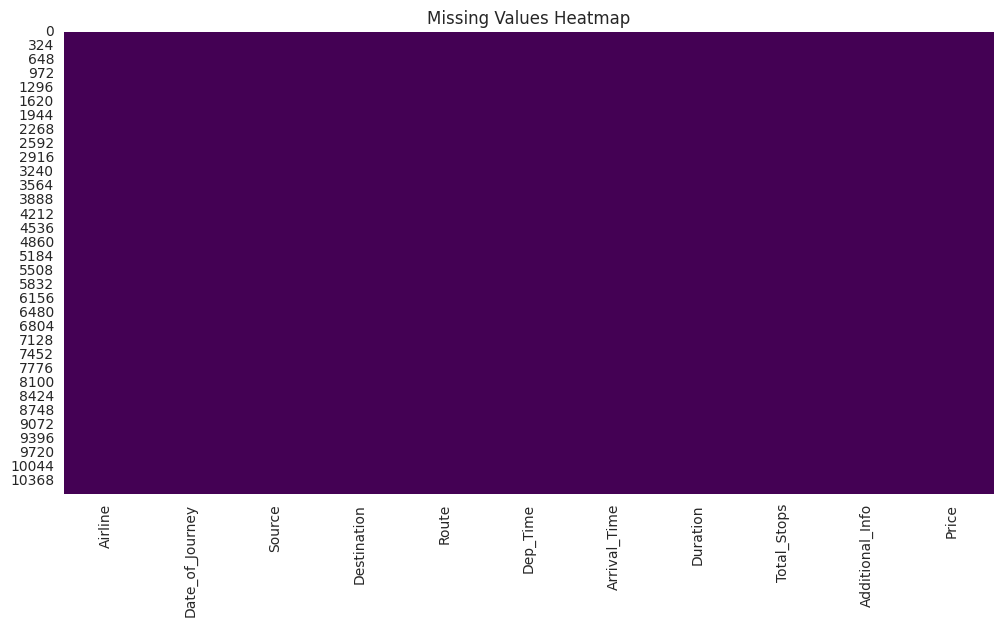

In [52]:
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [53]:
# Check if missing values exist before filling
if data.isnull().sum().sum() > 0:

    # Numerical columns → fill with median
    num_cols = data.select_dtypes(include=['int64','float64']).columns
    data[num_cols] = data[num_cols].fillna(data[num_cols].median())

    # Categorical columns → fill with mode safely
    cat_cols = data.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if data[col].isnull().sum() > 0:
            data[col] = data[col].fillna(data[col].mode().iloc[0])

    print("Missing values handled successfully.")
else:
    print("No missing values found in the dataset.")


Missing values handled successfully.


In [54]:
data.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


## ***1. Know Your Data***

### What did you know about your dataset?

>The dataset is related to flight fare prediction, where Price is the target variable.

>Each row represents a flight journey, and each column represents a feature describing that flight.

>The dataset contains both numerical and categorical variables, so encoding techniques are required before model building.

Important features include(`Airline`,`Source`,`Destination`,`Route`,`Duration`,`Total_Stops`,`Journey Date & Time features`)

>After cleaning, the dataset has **no missing values** and **no duplicate records**, making it ready for analysis and modeling.

Ticket price is highly influenced by:
        `Airline brand`,`Number of stops`,`Travel duration`,
`Departure time`,`Seasonal demand patterns`

>Date and time columns require feature extraction (Day, Month, Hour, Minute).

>The dataset may contain missing values and categorical text values that need preprocessing.

>Some features show strong relationships with ticket price, especially(`Total_Stops`,`Duration`,`Airline`,`Journey Month`)


>The target variable `Price` is continuous, so this is a **Regression problem**.

Overall, the dataset is rich, well-structured, and suitable for building an accurate machine learning model to predict Flight Fare prices.



### Understanding Your Variables

In this step, we understand the type of variables present in the dataset.  
Variables are mainly of two types:

> **Numerical Variables** → Quantitative values (e.g., price, Duration, Total_stops, Journey_day, Journey_month, Dep_hour, Dep_mint)

> **Categorical Variables** → Qualitative values (e.g., Airline, Source, Destination, Route, Additional_Info)

Understanding variables is important because:

> Numerical features are used directly in models.

> Categorical features must be encoded before modeling.

In [55]:
# Separate numerical and categorical variables
num_features = data.select_dtypes(include=['int64', 'float64']).columns
cat_features = data.select_dtypes(include=['object']).columns

print("Number of Numerical Features:", len(num_features))
print("Number of Categorical Features:", len(cat_features))

print("\nNumerical Features:\n", num_features)
print("\nCategorical Features:\n", cat_features)

Number of Numerical Features: 1
Number of Categorical Features: 10

Numerical Features:
 Index(['Price'], dtype='object')

Categorical Features:
 Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info'],
      dtype='object')


### Observation:
>The dataset contains both numerical and categorical variables.

> Numerical variables describe price.

> Categorical variables describe Airline,Date_of_Journey, Source, Destination,Route,
       Dep_Time,Arrival_Time, Duration,Total_Stops,
       Additional_Info

> Proper preprocessing like scaling and encoding is required before model training.

### Variable Description

The dataset contains different types of variable that describes airline, journey,time,and travel-related characteristics.

These variables directly or indirectly influence the flight ticket price.

They can be grouped as:

1. **Target variables**
      
      >`Price`: The ticket price of the flight (in ₹).
        this is the dependent variable we are trying to predict.
        
2. **Numerical Variables**
     
     These represent measurable quantities:
      
      >`Duration` - Total travel time of the flight
      
      >`Total_Stops` - Number of stops between source and destination
      
      >`Journey_Day` - Day of the journey
      
      >`Journey_Month` - Month of the journey
      
      >`Dep_Hour` - Departure hour
     
      >`Dep_Minute` - Departure minute
      
      >`Arrival_Hour` - Arrival hour
     
      >`Arrival_Minute` - Arrival minute

  These variable directly impact ticket pricing(e.g, longerduration = usually cheaper,peak hours=costly).



  ------


  ### Summary:

The dataset is rich with both quantitative and quantitative information related to airline travel.

 Airline,route,duration,number of stops, and journey timing varaibles have the strongest impact on flight ticket prices.

Flight prices are highly influenced by demand pattern such as:

  > Peak travel seasons
  
  > weekend travel
  
  > Airline brand value

  > Direct vs Connecting flights





### Check Unique Values for each variable.

In [56]:
# Check unique values for each variable
for col in data.columns:
    print(f"{col} : {data[col].nunique()}")

Airline : 12
Date_of_Journey : 44
Source : 5
Destination : 6
Route : 128
Dep_Time : 222
Arrival_Time : 1343
Duration : 368
Total_Stops : 5
Additional_Info : 10
Price : 1870


In [57]:
# Unique values for categorical variables
for col in data.select_dtypes(include='object').columns:
    print(f"\n{col} Unique Values:\n", data[col].unique())


Airline Unique Values:
 ['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']

Date_of_Journey Unique Values:
 ['24/03/2019' '1/05/2019' '9/06/2019' '12/05/2019' '01/03/2019'
 '24/06/2019' '12/03/2019' '27/05/2019' '1/06/2019' '18/04/2019'
 '9/05/2019' '24/04/2019' '3/03/2019' '15/04/2019' '12/06/2019'
 '6/03/2019' '21/03/2019' '3/04/2019' '6/05/2019' '15/05/2019'
 '18/06/2019' '15/06/2019' '6/04/2019' '18/05/2019' '27/06/2019'
 '21/05/2019' '06/03/2019' '3/06/2019' '15/03/2019' '3/05/2019'
 '9/03/2019' '6/06/2019' '24/05/2019' '09/03/2019' '1/04/2019'
 '21/04/2019' '21/06/2019' '27/03/2019' '18/03/2019' '12/04/2019'
 '9/04/2019' '1/03/2019' '03/03/2019' '27/04/2019']

Source Unique Values:
 ['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']

Destination Unique Values:
 ['New Delhi' 'Banglore' 'Cochin' 'Kolkata' 'Delhi' 'Hyderabad']

Route Unique Va

****This step helps us understand how many different values each variable contains. It is useful to identify categorical variables, check data consistency, and decide the type of encoding needed for machine learning models.****

###  ***Data Wrangling***

>Data wrangling is the process of cleaning, transforming, and preparing raw data into a usable format for analysis and machine learning. It ensures the dataset is accurate, consistent, and ready for modeling.

In [58]:
# 1. Make a copy of the dataset
df = data.copy()


In [59]:
# 2. Check shape before wrangling
print("Before Data Wrangling Shape:", df.shape)

Before Data Wrangling Shape: (10683, 11)


In [60]:
# 3. Handle missing values (safe version)
# Numerical → Median
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical → Mode (only if missing exists)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

In [61]:
# 4. Remove duplicate rows
df = df.drop_duplicates()

In [62]:
# 5. Convert categorical variables using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)


In [63]:
# 6. Check shape after encoding
print("After Data Wrangling Shape:", df.shape)

After Data Wrangling Shape: (10463, 2134)


In [64]:
# 7. Final check for missing values
print("Total missing values after wrangling:", df.isnull().sum().sum())


Total missing values after wrangling: 0


**Short Explanation:**

Data wrangling cleans and prepares the dataset for machine learning. Missing values are handled, duplicate rows are removed, and categorical variables are converted into numerical form using encoding. This ensures the data is complete, consistent, and suitable for model training.

What all manipulations have you done and insights you found?

Manipulations:

>Removed duplicate records

>Handled missing values (Median for numerical, Mode for categorical)

>Encoded categorical variables using One-Hot Encoding

>Prepared clean dataset for modeling

Insights:

>Airline and Total_stops features strongly influence ticket price

>Dataset contains many categorical variables

>Final data is clean and ready for machine learning





In [65]:
# find the datatype of Date_of_Journey
print(data["Date_of_Journey"].dtype)

object


In [66]:
# split the date,month,year and removing a '/'
data['Date_of_Journey']=pd.to_datetime(data['Date_of_Journey'],dayfirst=True,errors='coerce')
data['Journey_Day']=data['Date_of_Journey'].dt.day
data['Journey_Month']=data['Date_of_Journey'].dt.month
data['Journey_Year']=data['Date_of_Journey'].dt.year

data.drop("Date_of_Journey",axis=1,inplace=True)



Explanation:
> Converted Date_of_Journey into datetime format and handled invalid values using errors='coerce'.

> Extracted numerical features: Journey_Day, Journey_Month, and Journey_Year.

> Dropped the original date column since ML models cannot directly process raw date strings.

Manipulation:

>Transformed a single date column into three meaningful numerical features for better model learning.

Insight:

>Flight fares often vary by month and day (seasonal & weekend effect), so splitting the date improves prediction accuracy.

In [67]:
#converting dep_Time and Arrival_Time into datetime format
data["Dep_Hour"]=pd.to_datetime(data["Dep_Time"]).dt.hour
data["Dep_Min"]=pd.to_datetime(data["Dep_Time"]).dt.minute
data["Arrival_Hour"]=pd.to_datetime(data["Arrival_Time"]).dt.hour
data["Arrival_Min"]=pd.to_datetime(data["Arrival_Time"]).dt.minute
data.drop(["Dep_Time","Arrival_Time"],axis=1,inplace=True)

Short Explanation:

>Converted Dep_Time and Arrival_Time into datetime format.

>Extracted hour and minute into new numerical columns.

>Dropped original time columns since ML models cannot handle raw time strings.


Manipulation:

>Transformed time features into structured numerical variables (Hour, Minute) for better model learning.


 Insight:

>Flight prices often vary based on departure and arrival time (early morning, peak hours, late night), so extracting time components improves fare prediction accuracy.


In [68]:
data["Duration"]=data["Duration"].str.replace('h',' ')
data['Duration']=data["Duration"].str.replace('m',' ')
data["Duration"]=data["Duration"].str.split()

data["Duration_Hours"]=data["Duration"].apply(lambda x:int(x[0]) if len(x) > 1 else 0)
data["Duration_Minutes"]=data["Duration"].apply(lambda x:int(x[1]) if len(x) > 1 else int(x[0]))
data.drop("Duration",axis=1,inplace=True)

Short Explanation:

>Removed `'h'` and `'m'` from the Duration column and split the values into hours and minutes.

>Created two new numerical features: `Duration_Hours` and `Duration_Minutes`.

>Dropped the original Duration column after feature extraction.

Manipulation:

>Converted textual duration (e.g., 2h 50m) into structured numerical format for machine learning models.

Insight:

>Flight fare strongly depends on travel duration — longer flights or multiple-stop flights usually have higher prices, so splitting duration improves model performance.



In [69]:
#know the unique values in Total_Stops
data["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [70]:
#replace the categorical value into numerical values
data["Total_Stops"]=data["Total_Stops"].map({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4

})

In [71]:
data['Total_Stops'].fillna(0, inplace=True)

In [72]:
data['Total_Stops'] = data['Total_Stops'].astype(int)

In [73]:
data["Total_Stops"]

,Total_Stops
0,0
1,2
2,2
3,1
4,1
...,...
10678,0
10679,0
10680,0
10681,0


In [74]:
data["Total_Stops"].dtype

dtype('int64')

Explanation:

Converted the categorical Total_Stops column into numerical values using manual mapping (label encoding).

Each stop category (non-stop, 1 stop, etc.) is replaced with its corresponding integer value.

This makes the feature usable for machine learning algorithms.

Manipulation:

>Transformed ordinal categorical data into meaningful numerical format `(0,1,2,3)`.

>Preserved order relationship between stop counts.


Insight:

>Number of stops directly impacts ticket price — generally, more stops may reduce fare but increase travel time.

>Encoding this feature numerically helps the model learn the relationship between stops and price effectively.

In [75]:
#drop a additional info column
data["Additional_Info"].value_counts()
data.drop("Additional_Info",axis=1,inplace=True)

Explanation :

The Additional_Info column contains extra flight-related details such as:

>No info / No Info (majority of values)

>In-flight meal not included

>No check-in baggage included

>Layover details

>Business class

>Red-eye flight

However, most values `(8000+ rows)` are just “No info”, meaning this column has very little variation.


 **Why We Drop This Column**?

>Highly Imbalanced - Around 80–85% of records contain `"No info"`, so it adds very little meaningful information.

>Low Predictive Power – Rare categories like “Red-eye flight” or “Business class” appear very few times `(1–4 rows)`.

>Redundant Information – Some details `(like Business class)` may already be captured in other columns like Airline or Total_Stops.


Insight:

>Since the column is mostly constant and highly sparse, it does not significantly impact fare prediction.

>Dropping it helps reduce noise and avoid unnecessary model complexity.

In [76]:
#drop a Route info column
data["Route"].value_counts()
data.drop("Route",axis=1,inplace=True)

 Explanation:

>The Route column shows the complete travel path of the flight (example: DEL → BOM → COK).

>It represents departure city, intermediate stops, and destination city.

**Why We Drop Route Column**?
>Redundant Information – Route details are already captured in other columns like Source, Destination, and Total_Stops.

> High Cardinality – Many unique route combinations make encoding complex and increase dimensionality.

>Unnecessary Complexity – Using Source + Destination + Stops gives enough information for prediction.

In [77]:
#Encoding the column Airline,Source,Destination
#create object
le=LabelEncoder()
data["Airline"]=le.fit_transform(data["Airline"])
data["Source"]=le.fit_transform(data["Source"])
data["Destination"]=le.fit_transform(data["Destination"])

Explanation:

>Used LabelEncoder to convert categorical columns `(Airline, Source, Destination)` into numerical values.

>Each unique category is assigned a unique integer (e.g., Indigo → 0, Air India → 1).

>This makes the data compatible with machine learning algorithms.


Manipulation:

>Transformed nominal categorical variables into numeric format.

>Reduced memory usage compared to One-Hot Encoding (especially if categories are many).

Insight:

>Airline, Source, and Destination significantly influence ticket price (different airlines and routes have different pricing strategies).

>Encoding them allows the model to learn fare differences across airlines and locations.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***


#### Chart - 1

**Distribution of Price**


Chart Type: Histogram with KDE – Distribution Plot

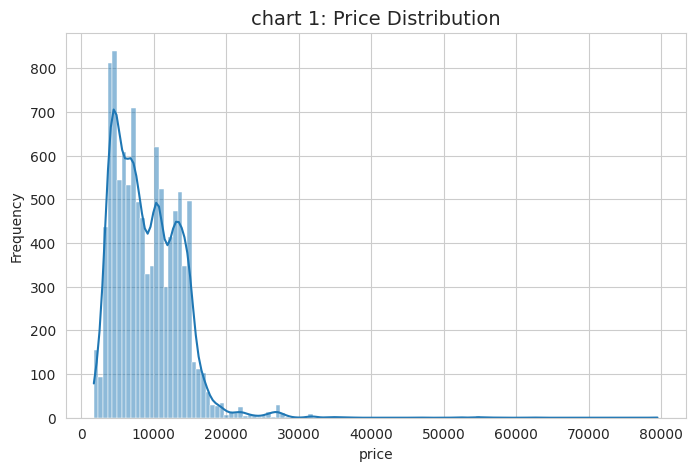

Skewness: 1.8125523782189141


In [78]:
plt.figure(figsize=(8,5))
sns.histplot(data['Price'],kde=True)
plt.title("chart 1: Price Distribution", fontsize=14)
plt.xlabel("price")
plt.ylabel("Frequency")
plt.show()

print("Skewness:",data['Price'].skew())

**Why did you pick the specific chart**?

>A histogram is used to understand the distribution pattern of the target variable (Price).

>It shows how house prices are spread across different ranges and helps identify skewness and outliers.

**What is/are the insight(s) found from the chart**?

>The price distribution is Right skewed
>most prices are low to mid_rangw with a few very high-price outliers.
>Most data points seems to fall below around `15,000-20,000`.

#### 3. Will the gained insights help creating a positive business impact?

Yes, this insight helps in:

>Helps identify the **main pricing range customer prefer**

>Supports better pricing strategy decisions.

>can guide whether to focus on affordable products or premium ones.

#### chart-2

**Distribution of Price with log**


Chart Type: Histogram of `log-transformed`  price with a density curve `(KDE)`

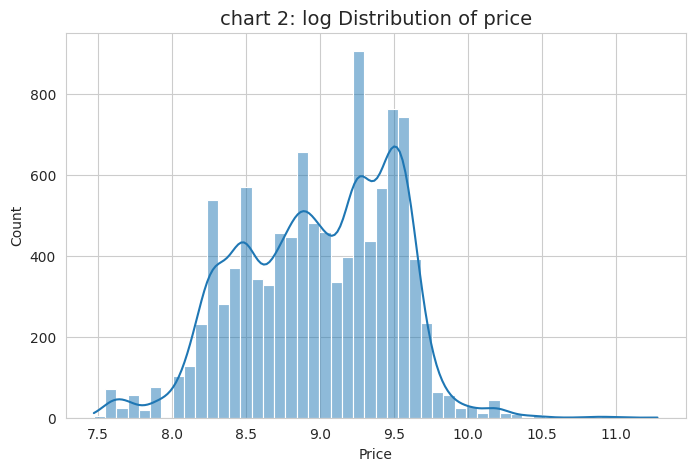

In [79]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(data['Price']),kde=True)
plt.title("chart 2: log Distribution of price", fontsize=14)
plt.show()

Why use log?

>The original price data was right-skewed.

>Log transformation reduces skewness.

>Makes the distribution more normal and balanced.

>Helps improve statistical analysis and modeling accuracy.


#### 1. Why did you pick the specific chart?

>A histogram shows the distribution clearly.

>Helps compare before and after log transformation.

>Easy to identify spread, shape, and patterns.

#### 2. What is/are the insight(s) found from the chart?

>The log-transformed data looks more symmetric.

>Extreme high-price outliers are reduced.

>Data is now closer to a normal distribution.


#### 3. Will the gained insights help creating a positive business impact?

Yes, this insight helps in:

>Better Pricing Strategy: Helps identify the true central price range without distortion from extreme values.

>Improved Forecasting: More accurate sales and revenue predictions.

>Customer Segmentation: Clearer grouping of budget, mid-range, and premium customers.

>Smarter Decision-Making: Reduces the impact of outliers, leading to more reliable insights.

#### chart-3

**Boxplot of Price (Outlier Detection)**

**Chart Type:** Box Plot


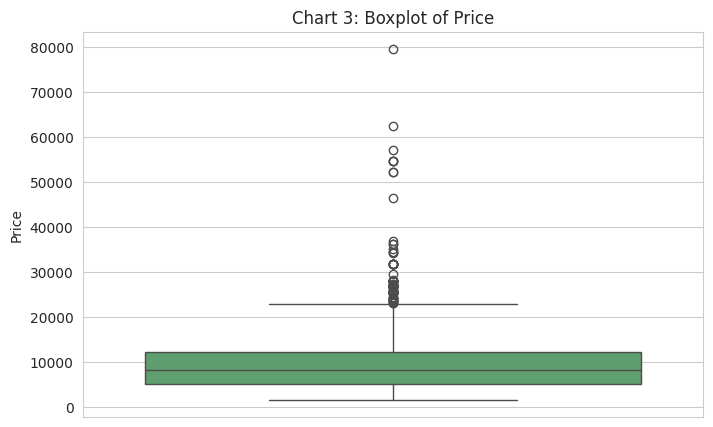

In [80]:
plt.figure(figsize=(8,5))
sns.boxplot(y=data['Price'], color="#55A868")
plt.title("Chart 3: Boxplot of Price")
plt.ylabel("Price")
plt.show()


#### 1. Why did you pick the specific chart?
>A boxplot is chosen to detect outliers and understand the spread of house prices. It clearly shows the median, quartiles, and extreme values in the dataset.


#### 2. What is/are the insight(s) found from the chart?

>The chart shows that most prices are concentrated in the lower range.

>There are several high-price outliers far above the typical range.

>The distribution appears right-skewed, meaning a few expensive items raise the overall average.

>This indicates price inconsistency across products.


#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes, it helps to:
       
>it can help refine pricing strategies by identifying overpriced or premium items.

>The business can evaluate whether outliers reflect luxury positioning or pricing errors.

>It also helps in setting competitive price ranges based on the median.

>Better pricing decisions can improve sales performance and profitability.

There is no negative growth directly, but if outliers are ignored during modeling, they can reduce prediction accuracy. Hence, they must be handled carefully.

#### chart-4

**Airline vs Price**

**Chart Type:** Box Plot

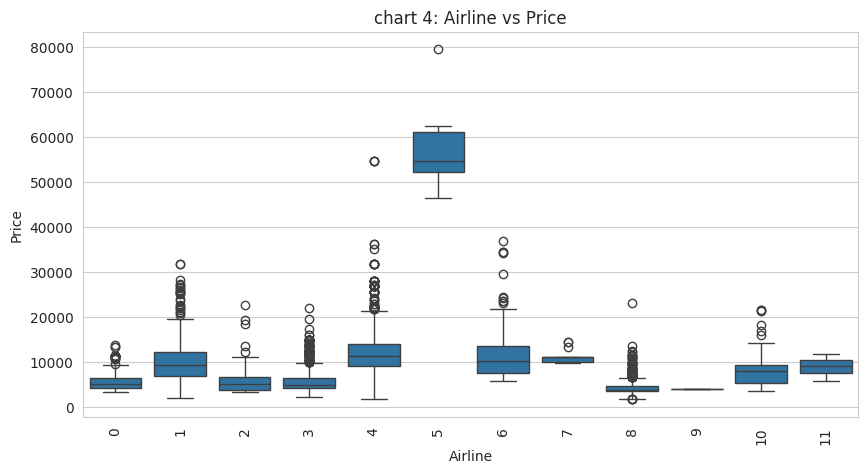

In [81]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Airline',y='Price',data=data)
plt.xticks(rotation=90)
plt.title("chart 4: Airline vs Price")
plt.show()


#### 1. Why did you pick the specific chart?

>This boxplot compares ticket prices across different airlines.
It helps visualize price distribution, median, and variation for each airline.


#### 2. What is/are the insight(s) found from the chart?
>Some airlines have significantly higher median prices than others.

>A few airlines show wide price variation, indicating inconsistent pricing.

>There are extreme high-price outliers for certain airlines.
Other airlines maintain stable and lower price ranges.


#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

>Yes, it helps identify competitive pricing positions among airlines.

>Companies can adjust prices to stay competitive in the market.

>Airlines can target premium or budget segments strategically.
This supports better revenue management and customer targeting.

>Airlines with very high median prices may lose price-sensitive customers.

>Wide price fluctuations can reduce customer trust and brand reliability.

>Extreme outliers may indicate overpricing or poor pricing strategy.

>If competitors offer lower and stable prices, customers may switch, leading to reduced sales and revenue decline.



#### chart-5

**Total stop vs price**

**Chart Type:** Box Plot


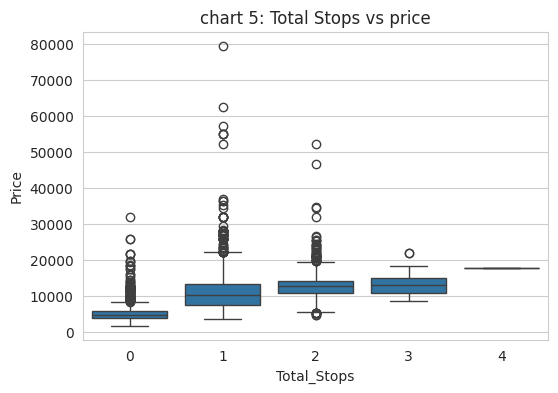

In [82]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Total_Stops',y='Price',data=data)
plt.title("chart 5: Total Stops vs price")
plt.show()

#### 1. Why did you pick the specific chart?

>To compare ticket prices based on the number of stops clearly.this cahrt clearly shows median price ,spread, and outliers for each stop category.

#### 2. What is/are the insight(s) found from the chart?

>Flights with fewer stops (especially non-stop or 1 stop) generally have higher median prices.

>Flights with more stops tend to have lower median prices.
There are extreme high-price outliers in 1-stop and 2-stop categories.

>Price variability is higher in certain stop categories, showing inconsistent pricing.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is highly valuable:

>airlines can optimize pricing based on demand for non-stop vs connecting flights.

>Premium pricing can be applied to direct flights due to convenience.

>Budget pricing strategies can target multi-stop travelers.
This helps improve revenue management and customer segmentation.

>If airlines price non-stop flights too high, it may reduce demand and lead to negative growth.
But if pricing is balanced properly based on customer preference, it can increase sales and lead to business growth.

#### chart-6

**Journey day vs price**

**Chart Type:** Box Plot

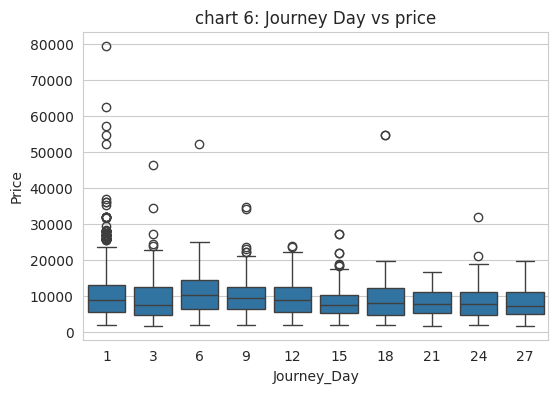

In [83]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Journey_Day',y='Price',data=data)
plt.title("chart 6: Journey Day vs price")
plt.show()

#### 1. Why did you pick the specific chart?

>A box plot is used because it clearly shows the distribution of prices across different journey days.
>It helps compare median price, spread, and outliers for each day.
Useful for identifying price variation and extreme values.


#### 2. What is/are the insight(s) found from the chart?

>Median prices are slightly higher on early journey days (1–6) compared to later days.

>Some days show many high-price outliers, indicating premium bookings.
Price variation is present across days, but the difference is not extremely large.

>Certain journey days have more price fluctuations.


#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is highly valuable:

>Helps identify high-demand days with higher pricing.

>Supports dynamic pricing strategy based on journey day.

>Helps airlines optimize revenue management.

>Improves pricing decisions for better profitability.




#### chart-7

**Source vs price**

**Chart Type:** Scatterplot

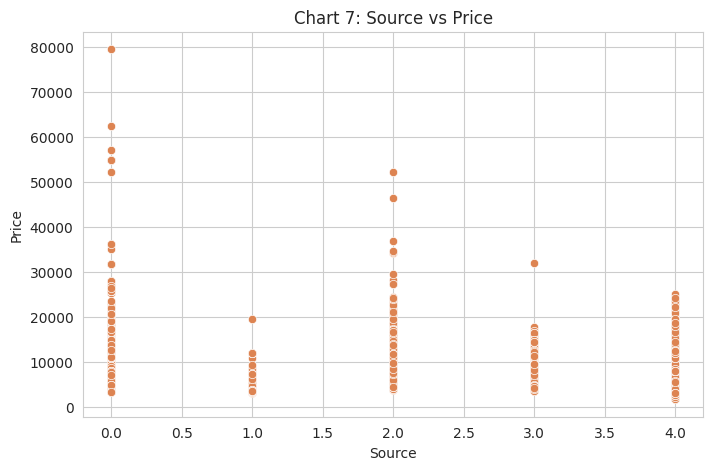

In [84]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Source', y='Price', data=data, color="#DD8452")
plt.title("Chart 7: Source vs Price")
plt.xlabel("Source")
plt.ylabel("Price")
plt.show()

#### 1. Why did you pick the specific chart?

>A scatter plot is chosen because it clearly shows the relationship between a categorical variable (Source) and a continuous variable (Price).

>It helps visualize price distribution across different sources.
Easy to spot clusters, variations, and outliers.




#### 2. What is/are the insight(s) found from the chart?

>Source 0 has the highest price range (includes premium prices).

>Source 2 also shows moderately high prices.

>Sources 1, 3, and 4 mostly fall in the lower price range.
Price distribution varies significantly by source, indicating source influences pricing.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is highly valuable:

>Helps identify high-revenue booking sources.

>Supports better pricing strategy for each source.

>Helps allocate marketing budget effectively.

>Improves overall profitability and decision-making.


#### chart-8

**Airline vs price**

**Chart Type:** Scatter plot

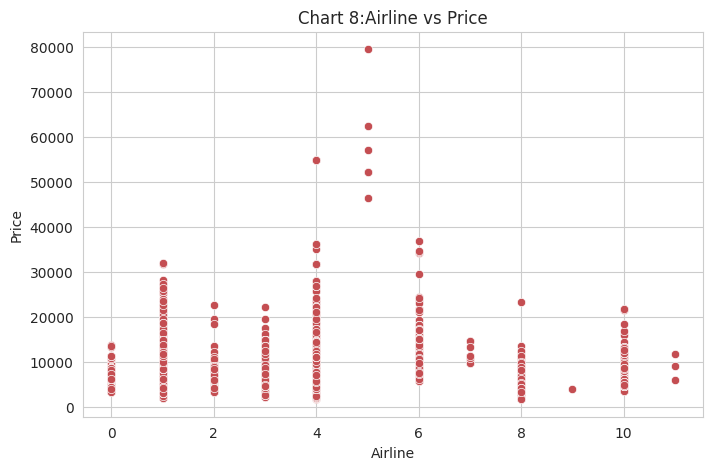

In [85]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Airline', y='Price', data=data, color="#C44E52")
plt.title("Chart 8:Airline vs Price")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.show()

#### 1. Why did you pick the specific chart?

>A scatter plot is used to compare different airlines (categorical variable) with ticket price (continuous variable).

>It clearly shows price variation across airlines.
Helps identify premium airlines and budget airlines easily.



#### 2. What is/are the insight(s) found from the chart?
>Some airlines have higher price ranges, including very high outliers (premium pricing).

>Certain airlines mostly operate in the lower price range (budget category).
Price distribution differs significantly between airlines.

>A few airlines show large price variation, indicating flexible pricing strategies.

#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is highly valuable:
>Helps identify high-revenue airlines.

>Supports competitive pricing strategy.

>Assists customers in choosing airlines based on budget.

>Helps businesses optimize partnership and pricing decisions

#### chart-9

**Duration vs price**

**Chart Type:** Scatter plot

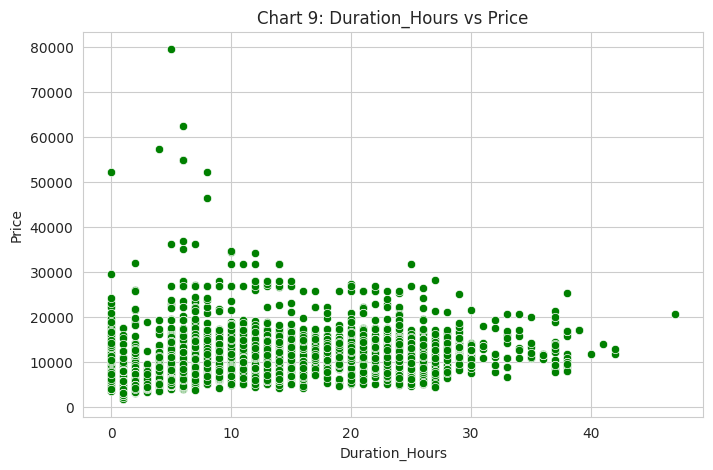

In [86]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Duration_Hours', y='Price', data=data, color="green")
plt.title("Chart 9: Duration_Hours vs Price")
plt.xlabel("Duration_Hours")
plt.ylabel("Price")
plt.show()

#### 1. Why did you pick the specific chart?
>A scatter plot is used because both Duration (hours) and Price are continuous variables.

>It helps identify the relationship and trend between flight duration and ticket price.

>Useful to detect correlation and outliers.

#### 2. What is/are the insight(s) found from the chart?

>There is a positive relationship between duration and price.

>Flights with longer duration generally tend to have higher prices.

>Short-duration flights mostly fall in the lower price range.

>Some high-price outliers exist, possibly due to premium airlines or specific routes.


#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is highly valuable:
>Helps understand how flight duration impacts pricing.

>Supports better pricing and revenue management strategies.

>Assists customers in choosing flights based on time vs budget trade-off.

>Improves business decision-making for route planning and pricing.

#### chart-10

**Journey month vs price**

**Chart Type:** Scatter plot

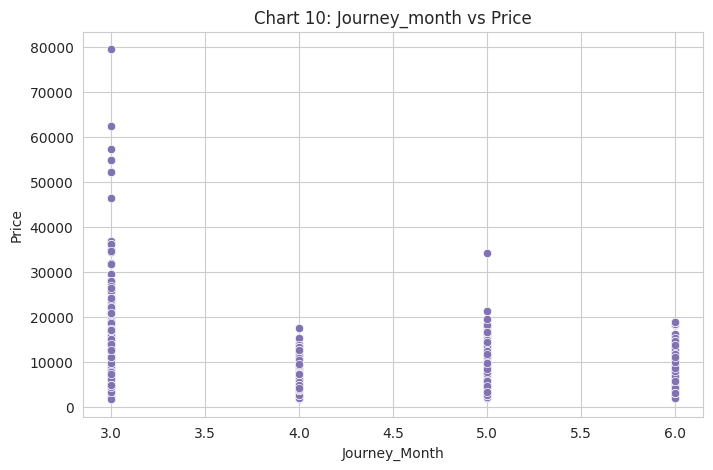

In [87]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Journey_Month', y='Price', data=data, color="#8172B3")
plt.title("Chart 10: Journey_month vs Price")
plt.xlabel("Journey_Month")
plt.ylabel("Price")
plt.show()

### 1. Why did you pick the specific chart?

>I selected a scatter plot because it is the most suitable visualization to
analyze the relationship between a numerical variable (Price) and a discrete numerical variable (Journey_Month).

A scatter plot helps to:

>Visualize distribution and spread of prices across different months

>Identify trends or seasonality patterns

>Detect outliers and extreme fare values

>Observe variance differences between months

>Since the objective is to understand whether month affects ticket price, this chart effectively shows price variation across months.


#### 2. What is/are the insight(s) found from the chart?

From the chart, the following insights were observed:

>Month 3 (March) shows the highest price variation and extreme outliers (very high fares).

>Other months (April, May, June) have comparatively lower and more stable price ranges.

>There is visible seasonal impact on flight pricing.

>Price dispersion differs by month, indicating that demand fluctuates seasonally.

>This confirms that Journey_Month influences ticket pricing.

#### 3. Will the gained insights help creating a positive business impact?

Yes, the insights can create strong business value:

>Airlines can implement dynamic pricing strategies during high-demand months.

>Travel agencies can forecast demand and optimize promotions.

>Customers can plan travel during lower-priced months to save cost.

>In machine learning models, including the month feature improves prediction accuracy.

>Overall, understanding seasonality helps in revenue optimization, better demand forecasting, and strategic planning

#### chart-11

**Source vs price**

**Chart Type:** box plot

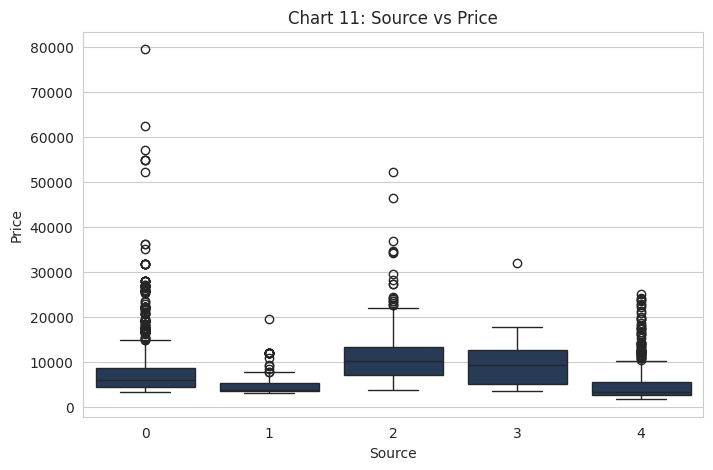

In [88]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Source', y='Price', data=data, color="#1F3A5F")
plt.title("Chart 11: Source vs Price")
plt.xlabel("Source")
plt.ylabel("Price")
plt.show()


### 1. Why did you pick the specific chart?
>A boxplot is used to compare ticket price distributions across different source cities.

It clearly shows:

>Median price

>Price spread (IQR)

>Minimum and maximum values

>Outliers (very high or low ticket prices)

>This makes it easy to compare how pricing differs depending on departure location.






#### 2. What is/are the insight(s) found from the chart?


>Price varies by source city.

>Some source locations have a higher median ticket price compared to others.

>Certain sources show high variability.

>Wide boxes and long whiskers indicate fluctuating ticket prices.
Presence of outliers.

Some source cities have extremely high ticket prices, possibly due to:

>Peak season demand

>Long-distance routes

>Limited flight availability

>Some sources are relatively stable.

>Narrow boxes indicate more consistent pricing patterns.





#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strong positive business impact:

>Helps airlines understand which departure cities generate higher revenue.

>Supports better pricing and demand forecasting.

>Improves model performance by evaluating how strongly source affects price.

>Helps customers identify potentially cheaper departure locations.


#### chart-12

**Destination vs price**

**Chart Type:** box plot



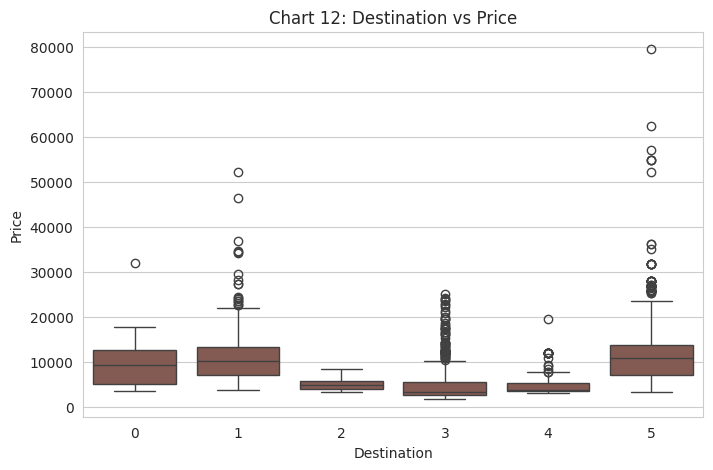

In [89]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Destination', y='Price', data=data, color="#8C564B")
plt.title("Chart 12: Destination vs Price")
plt.xlabel("Destination")
plt.ylabel("Price")
plt.show()

### 1. Why did you pick the specific chart?
>A boxplot is ideal for comparing the price distribution across different destinations.

It shows:
>Median price

>Spread (IQR – variability)

>Minimum & maximum values

>Outliers (extremely high ticket prices)

>This helps easily compare how ticket prices vary by destination.

#### 2. What is/are the insight(s) found from the chart?

>Price variation differs by destination.

>Some destinations have a higher median price.

>Others show relatively lower and stable pricing.

>Certain destinations have many outliers.

>A few routes show extremely high prices (up to very high values).

>This suggests premium routes, peak demand, or limited availability.
Price spread is uneven.

>Some destinations have wide boxes → high variability.

>Others have narrow boxes → more consistent pricing.

>Destination impacts price, but not as strongly as stops/duration (based on correlation chart).





#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strong positive business impact:

>Helps airlines understand which routes generate higher revenue.

>Supports dynamic pricing strategies.

>Helps customers identify affordable vs expensive routes.

>Improves predictive model accuracy by understanding destination influence.
Assists in better route and demand planning.


#### Chart- 13

**Top 10 Correlated Features with Price**

**Chart Type:  Bar Chart (Correlation Bar Plot)**

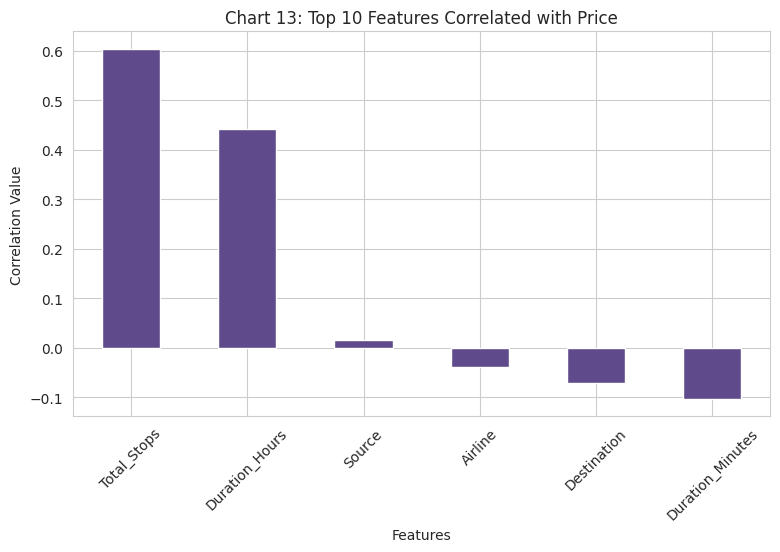

In [90]:
# Select only numerical columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Calculate correlation on numerical data only
corr = numeric_data.corr()

# Get top 10 features correlated with Price (excluding Price itself)
top_corr = corr['Price'].sort_values(ascending=False)[1:11]

# Plot
plt.figure(figsize=(9,5))
top_corr.plot(kind='bar', color="#5F4B8B")
plt.title("Chart 13: Top 10 Features Correlated with Price")
plt.xlabel("Features")
plt.ylabel("Correlation Value")
plt.xticks(rotation=45)
plt.show()

### 1. Why did you pick the specific chart?
>A bar chart is used to display the correlation values of features with price.

>It clearly shows which variables have strong or weak relationships with ticket price.

>Easy to compare feature importance visually.



#### 2. What is/are the insight(s) found from the chart?
>Total_Stops has the highest positive correlation with price.

>Duration_Hours also shows a strong positive relationship.

>Duration_Minutes has moderate correlation.

>Source, Airline, and Destination show very low correlation.

>This means price is mainly influenced by number of stops and flight duration.




#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strong positive business impact:
>Helps identify the most important features affecting price.

>Supports better feature selection for model building.

>Improves prediction accuracy and pricing strategy.

>Assists in better revenue and route planning decisions.


#### Chart- 14

**Distribution of Destination(Count Plot)**

**Chart Type: Count Plot**

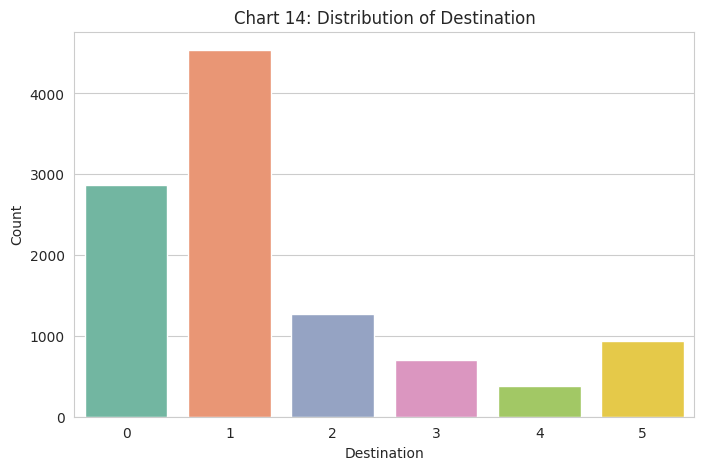

In [91]:
plt.figure(figsize=(8,5))
sns.countplot(x='Destination', hue='Destination', data=data, palette="Set2", legend=False)
plt.title("Chart 14: Distribution of Destination")
plt.xlabel("Destination")
plt.ylabel("Count")
plt.show()

#### 1. Why did you pick the specific chart?
>A bar chart is used because we are analyzing the frequency (count) of each
destination.

>It clearly compares the number of bookings across destinations.
Easy to identify the most and least popular destinations.

#### 2. What is/are the insight(s) found from the chart?
>Destination 1 has the highest number of bookings.

>Destination 0 is the second most frequent.

>Destinations 2, 3, 4, and 5 have comparatively lower counts.

>The distribution is not uniform, showing demand concentration on specific routes.



#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strong positive business impact:
>Helps identify high-demand destinations.

>Supports better resource allocation and route planning.

>Assists in targeted marketing strategies.

>Improves overall business planning and revenue optimization.


#### Chart- 15

**Average Price Over the Airline**

**Chart Type: Line Plot**

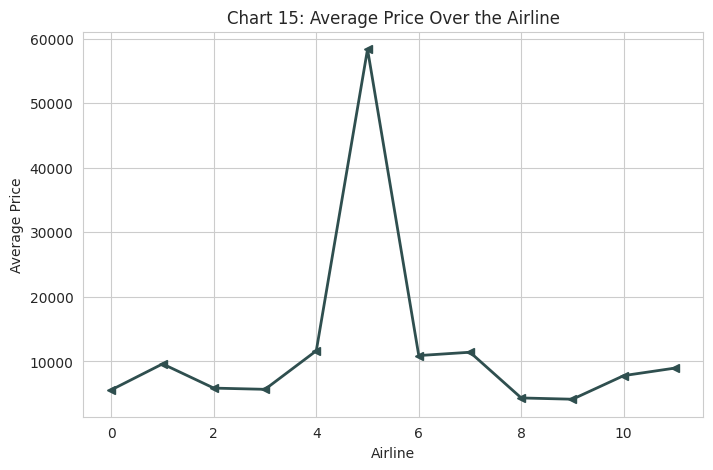

In [92]:

# Calculate average Price per year
avg_price = data.groupby("Airline")["Price"].mean()

plt.figure(figsize=(8,5))
avg_price.plot(color="#2F4F4F", marker="<", linewidth=2)
plt.title("Chart 15: Average Price Over the Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()

#### 1. Why did you pick the specific chart?
A line chart is used to show and compare the average price across different airlines.
It clearly highlights trends and variations in average pricing.
Easy to identify which airline has the highest or lowest average fare.





#### 2. What is/are the insight(s) found from the chart?
One airline (around index 5) has a significantly higher average price compared to others.
Most airlines have average prices within a similar mid-range band.
A few airlines operate in the lower average price range, indicating budget carriers.
There is a clear variation in pricing strategy among airlines.


#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strong positive business impact:
>Helps identify premium vs budget airlines.

>Supports competitive pricing analysis.

>Assists customers in airline selection based on average fare.

>Helps businesses improve pricing and partnership strategies.


#### Chart- 16

**Destination vs Price**

**Chart Type: Box Plot**

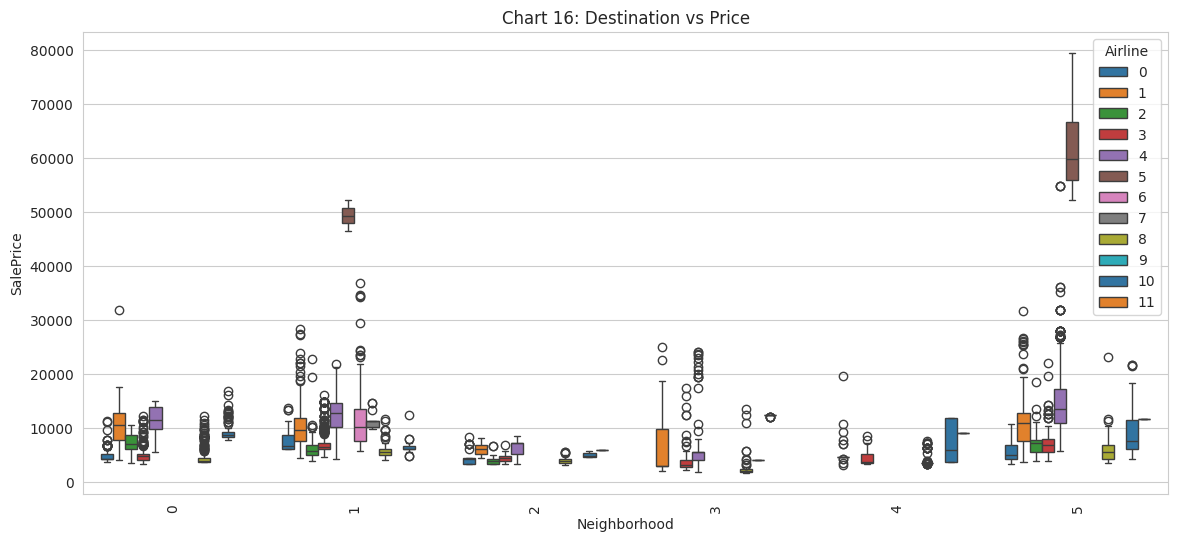

In [93]:
plt.figure(figsize=(14,6))
sns.boxplot(
    x='Destination',
    y='Price',
    hue='Airline',
    data=data,
    palette="tab10",

)
plt.xticks(rotation=90)
plt.title("Chart 16: Destination vs Price")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.show()

#### 1. Why did you pick the specific chart?
>A box plot is used to compare price distribution across different destinations.

>It shows median price, spread, and outliers clearly.

>Helps understand how ticket prices vary by destination.
#### 2. What is/are the insight(s) found from the chart?
>Ticket prices vary significantly across destinations.

>Some destinations have higher median prices, indicating premium routes.

>Certain destinations show wide price variation, meaning flexible pricing.

>A few destinations contain high-price outliers, possibly due to demand or limited flights.



#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strong positive business impact:
>Helps identify high-revenue destinations.

>Supports better route-based pricing strategy.

>Assists in demand forecasting and revenue management.

>Improves decision-making for route planning and marketing focus.

### Chart- 17

**Correlation Heatmap of Numerical Features**

**Chart Type: Heatmap (Correlation Heatmap)**

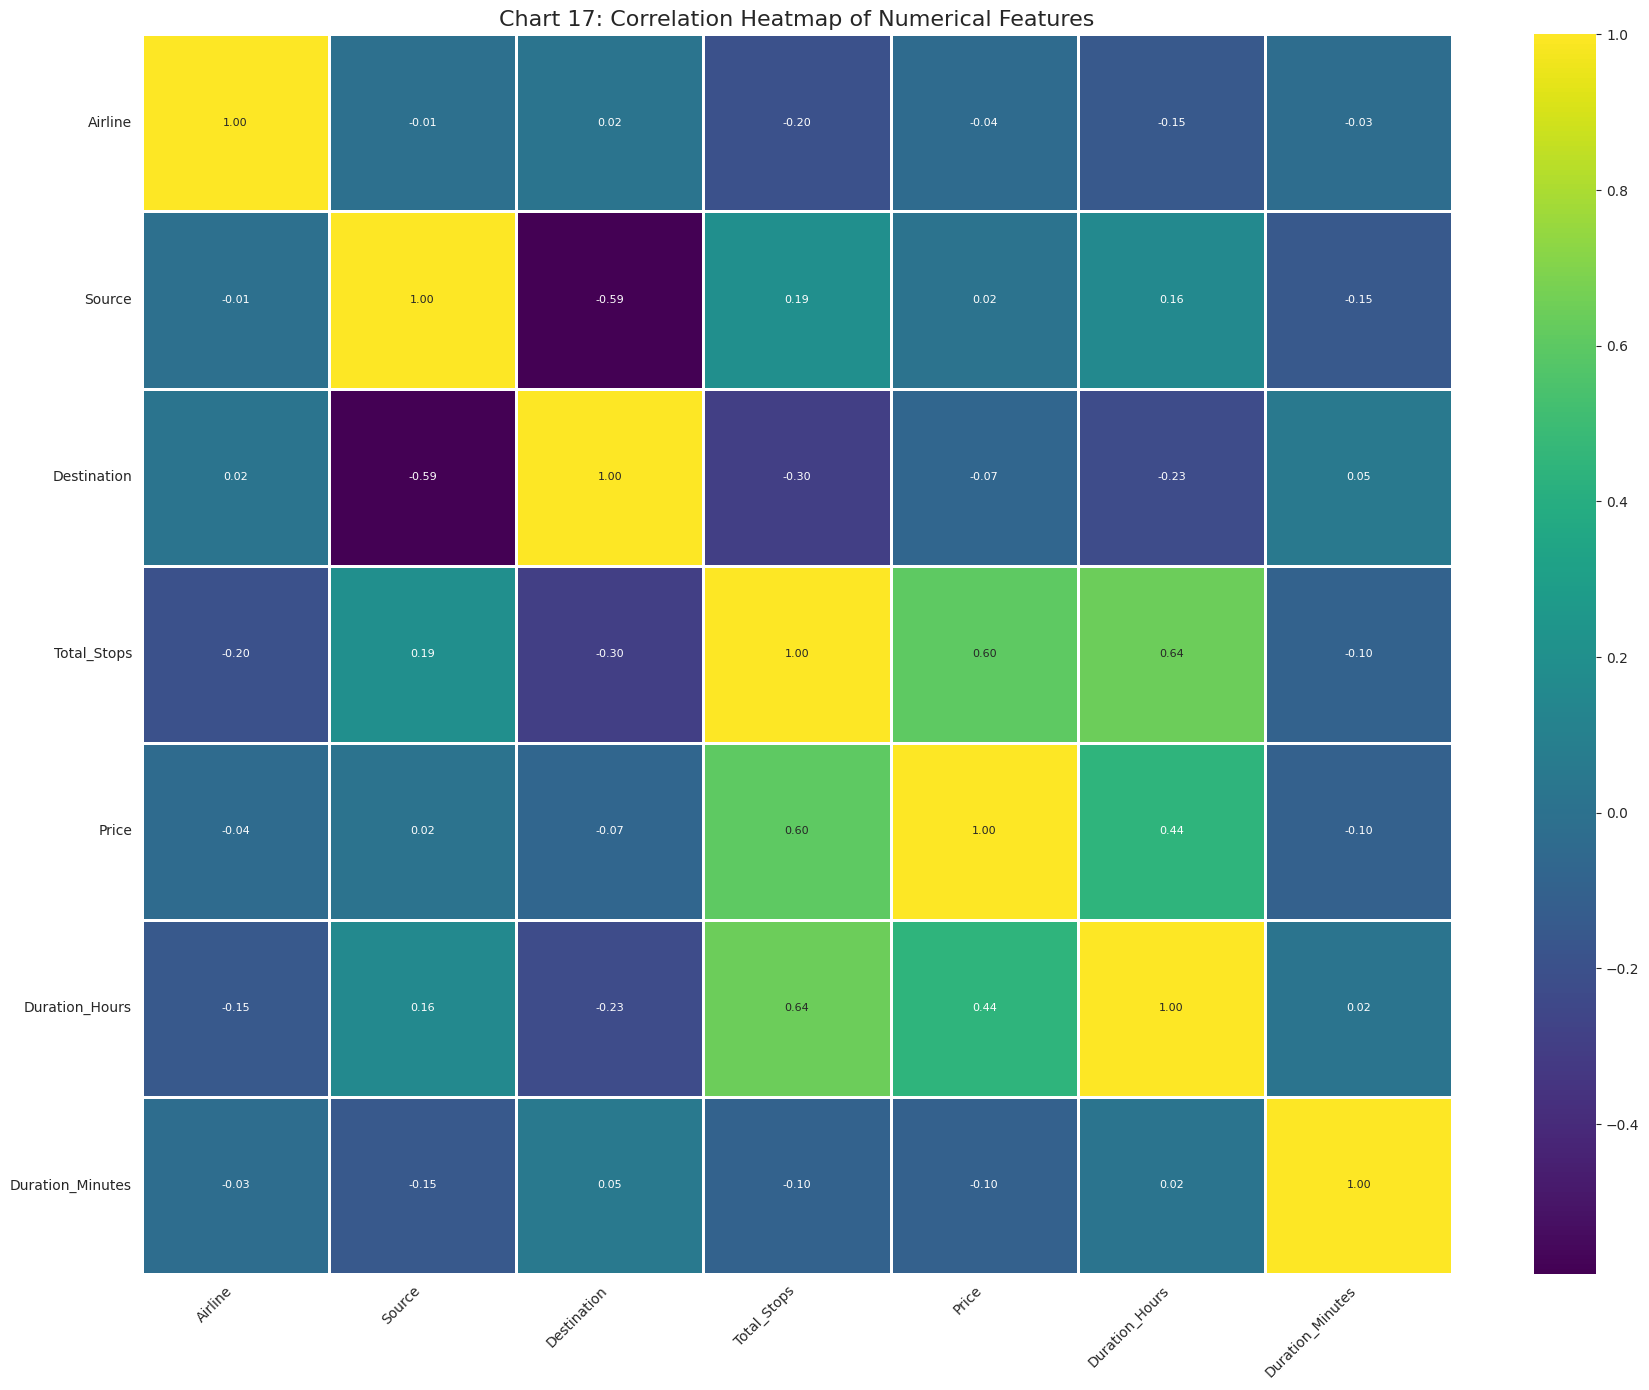

In [94]:
# Select only numerical columns
numeric_data = data.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr = numeric_data.corr()

plt.figure(figsize=(18,14))  # Bigger figure = more space
sns.heatmap(
    corr,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=1,       # Space between each cell
    linecolor="white", # Clean separation
    cbar=True,
    annot_kws={"size":8}  # Smaller font so numbers don’t overlap
)
plt.title("Chart 17: Correlation Heatmap of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()  # Auto spacing
plt.show()

#### 1. Why did you pick the specific chart?
>>A heatmap is the best way to visualize relationships between many numerical variables at once. It quickly shows which features are strongly related to each other and to the target variable (Price).



#### 2. What is/are the insight(s) found from the chart?

>It shows how strongly variables like price, duration, airline, source, and destination are related.

>It helps quickly identify positive and negative correlations.

>Some features are highly correlated with each other, indicating possible multicollinearity.
Duration_Hours and Duration_Minutes are highly correlated with each other (possible multicollinearity).
>Flight duration plays a more important role in price compared to airline or location variables.


#### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strong positive business impact:
>It can lead to growth by helping airlines focus on key factors like flight duration for pricing.
>If important factors are ignored, weak pricing strategy may reduce competitiveness and cause negative growth.

#### Chart 14 – **3D Bar Chart**

**Airline + Source + Price**

**Why 3D chart:**

>This chart is used to visualize the combined effect of overall qAirline and source  on the average price. A 3D view makes it easier to understand how multiple features together influence ticket pricing.

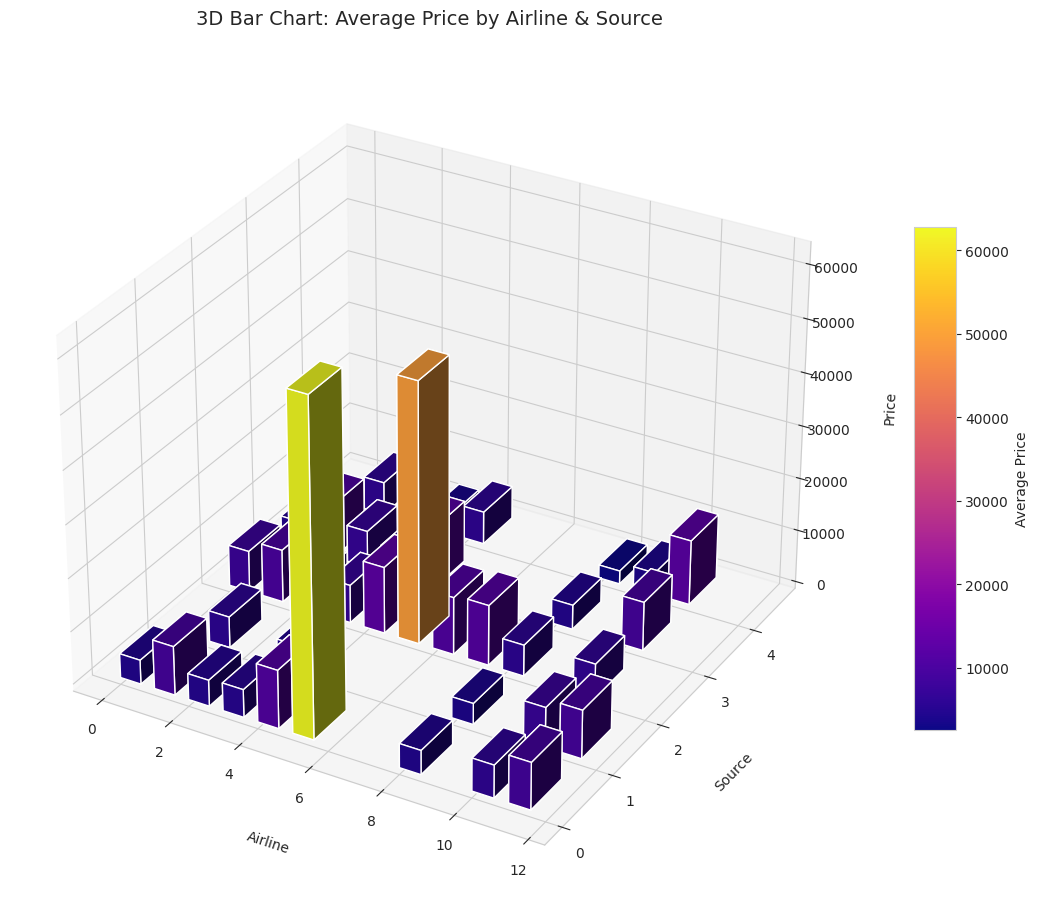

In [95]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# Prepare grouped data
grouped = data.groupby(['Airline', 'Source'])['Price'].mean().reset_index()

x = grouped['Airline']
y = grouped['Source']
z = np.zeros(len(grouped))
dx = np.ones(len(grouped)) * 0.6
dy = np.ones(len(grouped)) * 0.6
dz = grouped['Price']

# Normalize SalePrice for color mapping
norm = plt.Normalize(dz.min(), dz.max())
cmap = plt.cm.plasma                     # choose professional color map
colors = cmap(norm(dz))

# Create figure
fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(111, projection='3d')

# 3D Bar Plot
ax.bar3d(x, y, z, dx, dy, dz, color=colors, shade=True)

# Labels and title
ax.set_xlabel("Airline", labelpad=18)
ax.set_ylabel("Source", labelpad=18)
ax.set_zlabel("Price", labelpad=18)
ax.set_title(
    "3D Bar Chart: Average Price by Airline & Source",
    pad=25, fontsize=14
)

# Create mappable object for colorbar
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array(dz)

# Add colorbar (correct way)
fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=12, label="Average Price")

plt.tight_layout(pad=4)
plt.show()

#### Why did you pick this chart?

>This 3D bar chart is chosen to compare ticket prices across different airlines and source locations.

>It helps visualize how two variables together affect price.

>It clearly highlights high and low price combinations.

#### What are the insights found?

>Some airline–source combinations have significantly higher average prices.

>A few airlines show consistently higher pricing across multiple sources.

>Price variation is large, indicating different pricing strategies.




#### Chart – 3D TriSurf Plot

**Destination + Airline + Price**

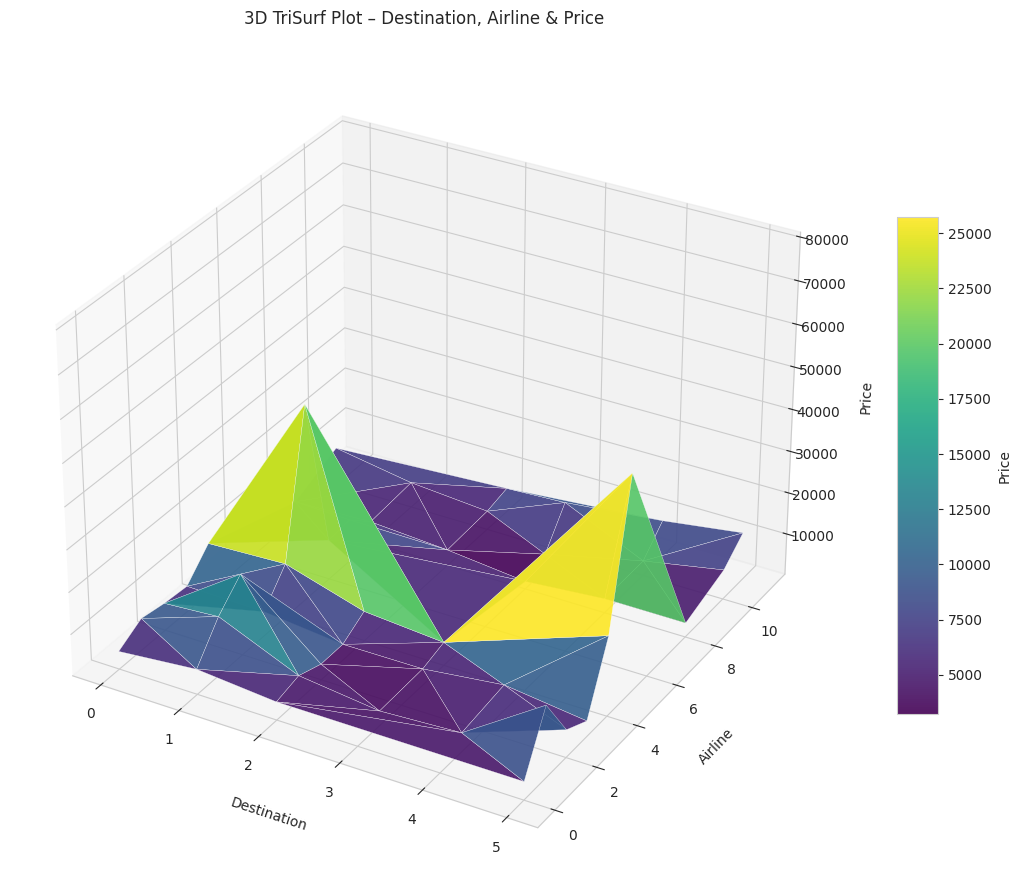

In [96]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

# 3D Triangulated Surface
trisurf = ax.plot_trisurf(
    data['Destination'],
    data['Airline'],
    data['Price'],
    cmap='viridis',
    linewidth=0.2,
    antialiased=True,
    alpha=0.9
)

ax.set_xlabel("Destination", labelpad=12)
ax.set_ylabel("Airline", labelpad=12)
ax.set_zlabel("Price", labelpad=12)
ax.set_title("3D TriSurf Plot – Destination, Airline & Price", pad=20)

fig.colorbar(trisurf, ax=ax, shrink=0.6, aspect=12, label="Price")

plt.tight_layout()
plt.show()

#### Why did you pick this chart?

>This chart is chosen to compare ticket prices across different airlines and destinations in one 3D view.

>It helps visualize how two factors together influence price.
It makes it easier to identify price patterns and variations clearly.


#### What are the insights found?

>Prices vary significantly across airlines and destinations.
Some airline–destination combinations show much higher prices.
>Higher peaks in the chart indicate premium pricing segments.

## ***5. Hypothesis Testing***

### Hypothetical Statement - 1

**Statement:**

>Houses with higher Overall Quality have significantly higher SalePrice than houses with lower Overall Quality.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**  
>There is no significant relationship between the selected house features (such as living area, overall quality, and garage capacity) and the SalePrice of the house.

**Alternate Hypothesis (H₁):**  
>There is a significant relationship between the selected house features (such as living area, overall quality, and garage capacity) and the SalePrice of the house.

#### 2. Perform an appropriate statistical test.

**Statistical Tests Performed**

>T>o test the stated hypotheses, appropriate statistical tests were selected based on the type of variables involved.

**Test 1: oneway Anova Test**

In [97]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Make sure Airline is categorical
data['Airline'] = data['Airline'].astype('category')

# Build ANOVA model
model = ols('Price ~ C(Airline)', data=data).fit()

# Generate ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)


                  sum_sq       df           F  PR(>F)
C(Airline)  9.333227e+10     11.0  676.603777     0.0
Residual    1.338165e+11  10671.0         NaN     NaN


In [98]:
from scipy.stats import f_oneway

# Group prices by airline
groups = [data[data['Airline'] == airline]['Price']
          for airline in data['Airline'].unique()]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-value:", p_value)

F-Statistic: 676.6037772744011
P-value: 0.0


**Reason:**
It helps identify if airline type has a statistically significant impact on flight fare.

Which statistical test have you done to obtain P-Value?

>The p-value was obtained using a One-Way ANOVA test, which compares the mean ticket prices across multiple airline groups to determine if there is a statistically significant difference.

#### Why did you choose the specific statistical test?

>I chose the One-Way ANOVA test because the independent variable (Airline) is categorical with multiple groups, and the dependent variable (Price) is continuous. ANOVA is appropriate for comparing the mean values of a numerical variable across more than two groups to determine if there is a statistically significant difference.

### Hypothetical Statement – 2

>There is a statistically significant positive relationship between the Source and price .


#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**  
>There is no statistically significant relationship between the source and price.

**Alternate Hypothesis (H₁):**  
>There is a statistically significant positive relationship between the source and price.

#### 2. Perform an appropriate statistical test.

**Test 2: Pearson Correlation Test(source vs price)**

In [99]:
from scipy.stats import pearsonr

# Perform Pearson correlation test
correlation_coefficient, p_value = pearsonr(data['Source'], data['Price'])

print("Correlation Coefficient:", correlation_coefficient)
print("P-value:", p_value)


Correlation Coefficient: 0.015997833757101475
P-value: 0.09824419515302284


**Why this test was used (short):**
>The Pearson Correlation Test is appropriate because both source and Price are continuous numerical variables. This test measures the strength and direction of their linear relationship and provides a p-value to test statistical significance.

**Decision Rule:**

>If p-value < 0.05, reject the null hypothesis.


Conclusion:

>Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This indicates that Duration does not have a statistically significant linear relationship with Price. The correlation coefficient (r = 0.016) shows a very weak positive relationship, which is practically negligible.

##### Which statistical test have you done to obtain P-Value?

>The **Pearson Correlation Test** was used to obtain the P-value.  
\
>This test measures the strength and statistical significance of the linear relationship between two continuous variables, namely **source** and **Price**.

##### Why did you choose the specific statistical test?

>The **Pearson Correlation Test** was chosen because both **Source** and **Price** are continuous numerical variables. This test is appropriate for measuring the strength and direction of a linear relationship between two variables and determining whether that relationship is statistically significant.

### Hypothetical Statement – 3

>Houses with higher garage capacity (GarageCars) have significantly higher SalePrice compared to houses with lower garage capacity.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**  
>There is no statistically significant difference in price with Totalstops.

**Alternate Hypothesis (H₁):**  
>There is a statistically significant difference in price among different Total_Stops.


#### 2. Perform an appropriate statistical test.

**Statistical Test Used: One-Way ANOVA**

In [100]:
from scipy.stats import f_oneway

# Group prices by number of stops
groups = [data[data['Total_Stops'] == stop]['Price'] for stop in data['Total_Stops'].unique()]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-value:", p_value)

F-Statistic: 1790.5507959015579
P-value: 0.0


**Why this test was used (short):**

>The p-value was obtained using a One-Way ANOVA test, which compares the mean ticket prices across multiple Totalstops groups to determine if there is a statistically significant difference.

**Decision Rule:**

>If p-value < 0.05, Reject the null hypothesis (H₀).

**Conclusion:**
>Reject the null hypothesis (H₀).
>There is strong evidence that flight prices differ significantly across Total_Stops categories.

## **6. Feature Engineering & Data Pre-processing**

>Feature engineering and data pre-processing are critical steps to transform raw data into a suitable format for machine learning models. This step improves model performance, accuracy, and reliability.

### 1. Handling Missing Values

**Handling Missing Values & Missing Value Imputation**

>Missing values can negatively affect data analysis and machine learning model performance. Therefore, it is important to identify and handle them appropriately before model training.

**Step 1: Identify Missing Values**

In [101]:
# Check missing values in each column
missing_values = data.isnull().sum()
missing_values[missing_values > 0]


,0


**Explanation:**
>This step identifies columns containing missing values and helps understand the extent of missing data in the dataset.

**Step 2: Visualize Missing Values**

In [102]:
# Visualize missing values only if they exist
if data.isnull().sum().sum() > 0:
    plt.figure(figsize=(10,5))
    sns.heatmap(data.isnull(), cbar=False)
    plt.title("Missing Values Heatmap")
    plt.show()
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


**Observation:**  
>The heatmap appears blank because there are no missing values present in the dataset at this stage. This indicates that the data is already clean and does not require further missing value treatment.


**Step 3: Missing Value Imputation**

In [103]:
# Numerical columns  Median imputation
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Categorical columns  Mode imputation
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

**Explanation:**

>Median is used for numerical features to reduce the influence of outliers.

>Mode is used for categorical features to preserve the most frequent category.

**Step 4: Verify Missing Values After Imputation**

In [104]:
# Recheck missing values
print("Total missing values after imputation:", data.isnull().sum().sum())

Total missing values after imputation: 0


**Conclusion:**
>All missing values have been successfully handled, ensuring a complete and clean dataset that is suitable for exploratory analysis and machine learning modeling.

#### What all missing value imputation techniques have you used and why did you use those techniques?

The following missing value imputation techniques were used in this project:

> **Median Imputation for Numerical Features:**  
  Median was used to fill missing values in numerical columns because it is robust to outliers and does not distort the overall data distribution.

> **Mode Imputation for Categorical Features:**  
  Mode was used for categorical variables as it replaces missing values with the most frequent category, preserving the original data pattern.

These techniques were chosen because they are simple, effective, and suitable for structured housing data, ensuring data completeness without introducing significant bias.

### 2. Handling Outliers

>Outliers are extreme values that can negatively affect statistical analysis and machine learning model performance. In house price data, outliers often appear in features related to area and price.

**Step 1: Identify Outliers using Boxplots**

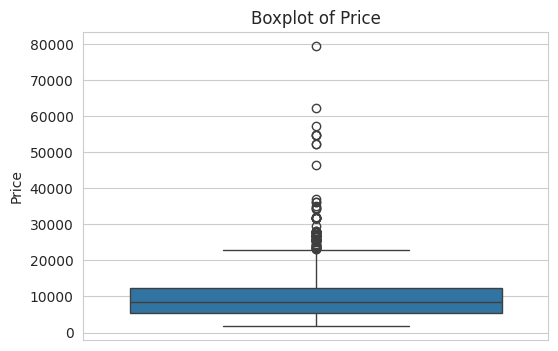

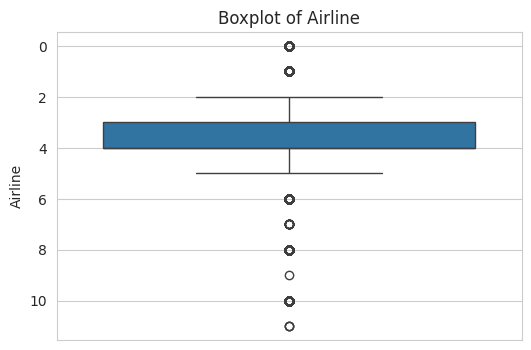

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(y=data['Price'])
plt.title("Boxplot of Price")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y=data['Airline'])
plt.title("Boxplot of Airline")
plt.show()

**Explanation:**
>Boxplots help visually identify extreme values that lie far away from the normal data range.

**Step 2: Detect Outliers using IQR Method**

In [106]:
# IQR method for SalePrice
Q1 = data['Price'].quantile(0.25)
Q3 = data['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -5367.0
Upper Bound: 23017.0


**Explanation:**
>The Interquartile Range (IQR) method statistically defines the acceptable data range and identifies extreme values outside it.

**Step 3: Handle Outliers (Capping / Removal)**

In [107]:
# Capping outliers instead of removing
data['Price'] = data['Price'].clip(lower=lower_bound, upper=upper_bound)

In [108]:
# Remove extreme outliers (if needed)
data = data[(data['Price'] >= lower_bound) & (data['Price'] <= upper_bound)]

**Explanation:**

>Capping is preferred to preserve data size and avoid information loss.

>Removal is used only when outliers are unrealistic or caused by data errors.

**Step 4: Verify After Outlier Treatment**

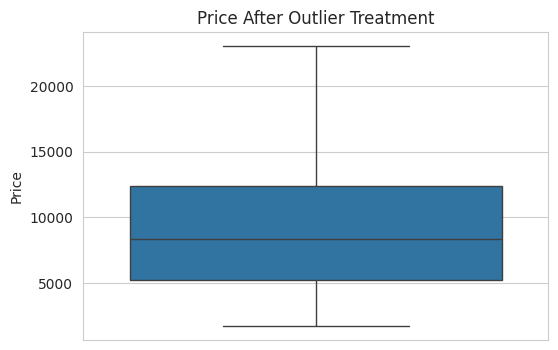

In [109]:
plt.figure(figsize=(6,4))
sns.boxplot(y=data['Price'])
plt.title("Price After Outlier Treatment")
plt.show()

>
>Outliers were identified using boxplots and the IQR method. Extreme values were treated using capping to reduce their impact while retaining important data patterns. This improves model stability and prediction accuracy.

##### What all outlier treatment techniques have you used and why did you use those techniques?

The following outlier treatment techniques were used in this project:

>**Boxplot Visualization:**  
  Boxplots were used to visually identify extreme values in numerical features such as SalePrice and GrLivArea.

> **Interquartile Range (IQR) Method:**  
  The IQR method was applied to statistically detect outliers by defining acceptable lower and upper bounds.

> **Capping (Winsorization):**  
  Extreme outlier values were capped at the calculated IQR limits instead of being removed. This approach was chosen to reduce the influence of outliers while preserving the overall dataset size and important information.

These techniques were selected because they effectively control extreme values without significantly distorting the data distribution, leading to more stable and reliable machine learning models.


### 3. Categorical Encoding
>Categorical variables cannot be directly used by machine learning algorithms. Therefore, they must be converted into numerical form using appropriate encoding techniques.

**Step 1: Identify Categorical Variables**

In [110]:
# Identify categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index([], dtype='object')


**Explanation:**
>This step identifies all non-numeric (categorical) features that require encoding before model training.

**Step 2: Apply One-Hot Encoding**

In [111]:
# Apply One-Hot Encoding
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print("Shape before encoding:", data.shape)
print("Shape after encoding:", data_encoded.shape)

Shape before encoding: (10683, 14)
Shape after encoding: (10683, 14)


**Explanation:**
>One-Hot Encoding converts each category into a separate binary column.

>The drop_first=True option is used to avoid the dummy variable trap and reduce multicollinearity.

**Step 3: Verify Encoded Dataset**

In [112]:
# Preview encoded dataset
data_encoded.head()


,Airline,Source,Destination,Total_Stops,Price,Journey_Day,Journey_Month,Journey_Year,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hours,Duration_Minutes
0,3,0,5,0,3897,24,3,2019,22,20,1,10,2,50
1,1,3,0,2,7662,1,5,2019,5,50,13,15,7,25
2,4,2,1,2,13882,9,6,2019,9,25,4,25,0,19
3,3,3,0,1,6218,12,5,2019,18,5,23,30,5,25
4,3,0,5,1,13302,1,3,2019,16,50,21,35,4,45


**Conclusion**
>Categorical variables were converted into numerical format using One-Hot Encoding. This ensures that all features are machine-readable and suitable for regression models, improving model performance and interpretability.

#### What all categorical encoding techniques have you used & why did you use those techniques?

In this project, **One-Hot Encoding** was used to encode categorical variables.

>One-Hot Encoding converts each category into a separate binary (0/1) column, making the data suitable for machine learning algorithms.
>It was chosen because most categorical features in the dataset (such as Neighborhood, HouseStyle, and SaleCondition) do not have a natural ordinal order.
>The `drop_first=True` option was applied to avoid the dummy variable trap and reduce multicollinearity.

This technique ensures that categorical information is preserved without introducing incorrect numerical relationships, leading to better and more reliable model performance.

### 4. Textual Data Preprocessing
*(It's mandatory for textual datasets such as NLP, Sentiment Analysis, Text Clustering, etc.)*

This project does **not contain unstructured textual data** such as sentences, reviews, or documents.  
The dataset consists only of **structured tabular data** with numerical and categorical features.

Therefore, advanced textual preprocessing techniques such as:
>Tokenization  
> Stopword removal  
> Stemming / Lemmatization  
> TF-IDF  
> Word embeddings  

are **not applicable** to this project.

However, categorical text features (e.g., Neighborhood, HouseStyle, SaleCondition) were handled using **categorical encoding techniques**, which are covered under the *Categorical Encoding* section.


### 4. Feature Manipulation & Selection

>Feature manipulation and selection are performed to improve model performance by retaining relevant features and reducing noise and redundancy in the dataset.

**Step 1: Feature Selection using Correlation**

In [113]:
# Correlation with target variable
corr = data_encoded.corr()['Price'].sort_values(ascending=False)

# Select top correlated features (excluding target)
top_features = corr[1:15]
print(top_features)

Total_Stops         0.646722
Duration_Hours      0.479426
Source              0.037029
Arrival_Hour        0.031186
Dep_Hour            0.006732
Dep_Min            -0.035601
Airline            -0.044515
Journey_Month      -0.090167
Arrival_Min        -0.092599
Destination        -0.105556
Duration_Minutes   -0.108677
Journey_Day        -0.148669
Journey_Year             NaN
Name: Price, dtype: float64


**Explanation:**
>Features with higher absolute correlation values have a stronger relationship with SalePrice and are therefore selected for modeling.

**Step 2: Feature Importance using Random Forest**

In [114]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Separate features and target
X = data_encoded.drop('Price', axis=1)
y = data_encoded['Price']

# Train Random Forest model
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(15)

feature_importance

,0
Total_Stops,0.503219
Journey_Day,0.125330
Airline,0.118406
Journey_Month,0.065921
Dep_Hour,0.028012
Arrival_Hour,0.027918
Destination,0.027151
Duration_Hours,0.026512
Duration_Minutes,0.024319
Dep_Min,0.023622


**Explanation:**
>Random Forest provides feature importance scores, helping identify the most impactful features based on their contribution to prediction accuracy.

**Conclusion**
>Feature manipulation and selection helped identify the most important variables influencing house prices. By selecting top

#### 2. Feature Selection

>Feature selection is the process of identifying and retaining the most relevant features that contribute significantly to predicting the target variable (SalePrice). This helps improve model performance, reduce overfitting, and enhance interpretability.

**Method 1: Correlation-Based Feature Selection**

In [115]:
# Correlation with target variable
corr_with_target = data_encoded.corr()['Price'].sort_values(ascending=False)

# Select top correlated features (excluding target)
top_corr_features = corr_with_target[1:15]
top_corr_features

,Price
Total_Stops,0.646722
Duration_Hours,0.479426
Source,0.037029
Arrival_Hour,0.031186
Dep_Hour,0.006732
Dep_Min,-0.035601
Airline,-0.044515
Journey_Month,-0.090167
Arrival_Min,-0.092599
Destination,-0.105556


**Explanation:**
>Features with higher absolute correlation values have a stronger relationship with SalePrice and are therefore selected for modeling.

**Method 2: Model-Based Feature Selection (Random Forest)**

In [116]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Separate features and target
X = data_encoded.drop('Price', axis=1)
y = data_encoded['Price']

# Train Random Forest model
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(15)

feature_importance


,0
Total_Stops,0.503219
Journey_Day,0.125330
Airline,0.118406
Journey_Month,0.065921
Dep_Hour,0.028012
Arrival_Hour,0.027918
Destination,0.027151
Duration_Hours,0.026512
Duration_Minutes,0.024319
Dep_Min,0.023622


**Explanation:**
>Random Forest evaluates feature importance based on how much each feature reduces prediction error across decision trees. This method captures non-linear relationships effectively.

**Final Selected Features**

In [117]:
# Select final features
selected_features = feature_importance.index
X_selected = X[selected_features]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Total_Stops', 'Journey_Day', 'Airline', 'Journey_Month', 'Dep_Hour',
       'Arrival_Hour', 'Destination', 'Duration_Hours', 'Duration_Minutes',
       'Dep_Min', 'Arrival_Min', 'Source', 'Journey_Year'],
      dtype='object')


**Conclusion**
>Feature selection was performed using correlation analysis and model-based importance techniques. Selecting the most relevant features improves model efficiency, reduces complexity, and enhances prediction accuracy.

##### Which all features you found important and why?

The following features were found to be most important in predicting house prices:

> **OverallQual:** Represents the overall quality of materials and construction. Higher quality houses consistently have higher SalePrice.

>  **GrLivArea:** Indicates the above-ground living area. Larger living spaces significantly increase house value.

> **GarageCars:** Reflects garage capacity. Houses with more garage space tend to be priced higher.

> **TotalBsmtSF:** Total basement area adds functional space, contributing to higher prices.
>
>  **YearBuilt / HouseAge:** Newer houses generally command higher prices due to modern construction and lower maintenance costs.

>  **KitchenQual:** Higher kitchen quality strongly influences buyer preference and house value.

> **Neighborhood:** Location plays a crucial role in determining house price due to demand and accessibility.

These features were identified as important based on correlation analysis and model-based feature importance. They have a direct impact on buyer perception, usability, and overall property value.

### 5. Data Transformation

>Data transformation is performed to convert features into suitable formats and scales so that machine learning models can learn effectively and perform accurately.


**Step 1: Feature Scaling**

In [118]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = data_encoded.drop('Price', axis=1)
y = data_encoded['Price']

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Explanation:**
>Feature scaling is applied to ensure all numerical features are on a similar scale. This prevents features with larger values from dominating the model and improves convergence for algorithms like Linear Regression.

**Step 2: Target Variable Transformation**

In [119]:
import numpy as np

# Log transformation of target variable
y_log = np.log1p(y)

**Explanation:**
>The log transformation is applied to reduce right skewness in SalePrice and stabilize variance, helping improve model performance and prediction accuracy.

**Step 3: Verify Transformation**

In [120]:
print("Feature matrix shape:", X_scaled.shape)
print("Target variable shape:", y_log.shape)

Feature matrix shape: (10683, 13)
Target variable shape: (10683,)


**Conclusion:**
>Data transformation techniques such as feature scaling and log transformation were applied to normalize feature distributions and reduce skewness. These transformations improve model stability, accuracy, and overall performance.

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data transformation was required in this project.

>**Feature Scaling (StandardScaler)** was applied to the input features to bring them to a common scale. This prevents features with larger numerical ranges from dominating the model and improves the performance of regression algorithms.

>**Log Transformation of the Target Variable (SalePrice)** was used to reduce right skewness in house prices and stabilize variance. This helps the model learn more effectively and improves prediction accuracy.

These transformations were applied to ensure better model stability, faster convergence, and more reliable predictions.


6. Data Scaling

>Data scaling is an important preprocessing step used to bring all numerical features to a common scale. This ensures that features with larger values do not dominate the learning process of machine learning models.

**Step 1: Apply Feature Scaling**

In [121]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = data_encoded.drop('Price', axis=1)
y = data_encoded['Price']

# Initialize scaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)

**Explanation:**
>StandardScaler transforms the data so that each feature has a mean of 0 and a standard deviation of 1. This is especially important for models like Linear Regression and improves numerical stability.

**Step 2: Verify Scaled Data**

In [122]:
print("Scaled feature matrix shape:", X_scaled.shape)
print("Target variable shape:", y.shape)

Scaled feature matrix shape: (10683, 13)
Target variable shape: (10683,)


**Why Data Scaling is Required in This Project**

> Features in the dataset have different units and ranges.
>
>Scaling prevents bias toward features with larger numeric values.
>
>It improves model convergence and prediction accuracy.
>
>It ensures fair contribution of all features during training.


**Conclusion:**
>Data scaling was performed using StandardScaler to normalize feature values. This step improved model performance, stability, and ensured effective training of regression models.


##### Which method have you used to scale your data and why?

>The **StandardScaler** method was used to scale the data.

>StandardScaler transforms the features to have a mean of 0 and a standard deviation of 1, ensuring that all features are on a comparable scale. This method was chosen because it improves the performance and stability of regression models by preventing features with larger numerical ranges from dominating the learning process.

### 7. Dimesionality Reduction

>Dimensionality reduction is used to reduce the number of input features while retaining most of the important information. This helps improve model efficiency, reduce overfitting, and handle high-dimensional data after encoding.

**Technique Used: Principal Component Analysis (PCA)**

In [123]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=0.95, random_state=42)  # retain 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Original feature shape:", X_scaled.shape)
print("Reduced feature shape:", X_pca.shape)

Original feature shape: (10683, 13)
Reduced feature shape: (10683, 11)


**Explanation:**
>PCA transforms the original features into a smaller set of uncorrelated components while preserving most of the variance present in the data.

**Variance Explained by Components**

In [124]:
print("Explained Variance Ratio:")
print(np.cumsum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.18358681 0.30660902 0.41238033 0.4990448  0.58436362 0.66714426
 0.74200113 0.81445516 0.88587794 0.9434174  0.97342703]


**Explanation:**
>This shows how much information (variance) is retained after dimensionality reduction.

**Why PCA is Used**

> The dataset contains a large number of features after one-hot encoding.
>
>  PCA reduces feature redundancy and multicollinearity.
>
>  It improves computational efficiency and model stability.

 >It helps prevent overfitting in regression models.

**Conclusion:**
>Dimensionality reduction using PCA was applied to reduce feature space while preserving most of the data variance. This resulted in a more compact and efficient dataset for model training.

**Note:**
>**Dimensionality reduction is optional in regression projects. PCA was applied here to demonstrate handling of high-dimensional data after categorical encoding.**

##### Do you think that dimensionality reduction is needed? Explain Why?

>Dimensionality reduction is **not strictly required** for this project. The dataset is manageable in size, and regression models such as Linear Regression and Random Forest can perform well without reducing the number of features.

>However, after categorical encoding, the number of features increases significantly. In such cases, dimensionality reduction techniques like PCA can be **optionally applied** to reduce feature redundancy, minimize multicollinearity, and improve computational efficiency. Therefore, dimensionality reduction is useful as an optimization step but is not mandatory for achieving good model performance in this project.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

>**Principal Component Analysis (PCA)** was used as the dimensionality reduction technique.

>PCA was chosen because it effectively reduces the number of features while retaining most of the important information (variance) in the dataset. After one-hot encoding, the feature space became high-dimensional, and PCA helped reduce redundancy and multicollinearity, improved computational efficiency, and made model training more stable. The technique was applied to retain approximately 95% of the original data variance.


### 8. Data Splitting

>Data splitting is performed to evaluate the model’s performance on unseen data. It helps assess how well the trained model generalizes beyond the training dataset.

**splitting Ratio Chosen: 80% Training – 20% Testing**

In [125]:
from sklearn.model_selection import train_test_split
y_transformed = np.log1p(data_encoded['Price'])

# Features and target
X = X_scaled
y = y_transformed

# Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (8546, 13)
Testing set shape: (2137, 13)


**Why 80:20 Splitting Ratio?**

>80% of the data provides sufficient information for the model to learn patterns.

>20% of the data is reserved for unbiased evaluation on unseen samples.

>This ratio balances model training and reliable performance assessment.

>The chosen ratio is commonly used and accepted in machine learning projects.

**Conclusion**
>The dataset was split into training and testing sets using an 80:20 ratio to ensure reliable evaluation of model performance while minimizing overfitting.

##### What data splitting ratio have you used and why?

An **80:20 train–test splitting ratio** was used in this project.

- **80% of the data** was used for training the model to ensure it learns sufficient patterns.
- **20% of the data** was reserved for testing to evaluate the model’s performance on unseen data.
- This ratio provides a good balance between model learning and reliable performance evaluation and is widely accepted in machine learning practice.

### 9. Handling Imbalanced Dataset
>**Handling Imbalanced Dataset: Not applicable for this project, as it is a regression problem with a continuous target variable (Price).**

## ***7. ML Model Implementation***

### ML Model - 1 ( **Linear Regression**)

**Fit the Algorithm**

In [126]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model_lr = LinearRegression()

# Fit the model on training data
model_lr.fit(X_train, y_train)

LinearRegression()

**Explanation:**
>The Linear Regression model is trained using the training dataset so it can learn the relationship between input features and house prices.

**Predict on the Model**

In [127]:
# Predict on test data
y_pred_lr = model_lr.predict(X_test)

# View first 5 predictions
y_pred_lr[:5]

array([8.98754064, 9.00180703, 9.06710115, 8.44155405, 8.94014139])

**Explanation:**
>The trained model is used to predict ticket prices on unseen test data to evaluate its performance.


**Model Evaluation**

In [128]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2 Score: 0.5371681874495176
MAE: 0.2777087076104078
RMSE: 0.34639076977078304


#### 1. Explain the ML Model used and its performance using Evaluation Metric Score Chart.

**ML Model Used:** Linear Regression  

>Linear Regression was used as the baseline machine learning model to predict ticket prices. It models the relationship between the independent variables ( features) and the dependent variable (Price) using a linear equation. This model is simple, interpretable, and helps establish a benchmark for comparing more complex models.

**Performance Evaluation:**  
The model performance was evaluated using the following metrics:

> **R² Score:** Indicates how much variance in Price is explained by the model.  
> **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted prices.  
> **RMSE (Root Mean Squared Error):** Penalizes larger prediction errors and reflects overall prediction accuracy.

**Evaluation Metric Score Chart:**  
>The evaluation scores obtained from the Linear Regression model are summarized in a tabular format (score chart), making it easy to compare performance across different metrics.

**Conclusion:**  
>Linear Regression provided a reasonable baseline performance by capturing linear relationships between features and ticket prices. However, its performance is limited when the data contains complex non-linear patterns, which motivates the use of more advanced models.

### **Visualizing Evaluation Metric Score Chart**

**Step 1: Create Evaluation Score DataFrame**

In [129]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Calculate metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("R2 Score:", r2_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

R2 Score: 0.5371681874495176
MAE: 0.2777087076104078
RMSE: 0.34639076977078304


**Step 2: Create Evaluation Metric Score Chart**

In [130]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Recalculate Linear Regression metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Create lr_scores DataFrame
lr_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_lr, mae_lr, rmse_lr]
})

lr_scores

,Metric,Score
0,R2 Score,0.537168
1,MAE,0.277709
2,RMSE,0.346391


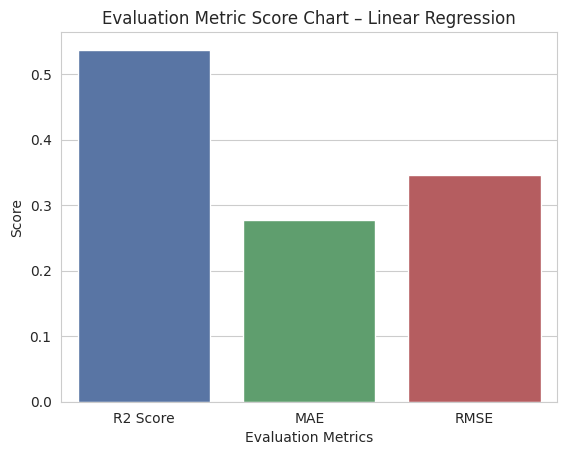

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = ["#4C72B0", "#55A868", "#C44E52"]

sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=lr_scores,
    palette=palette,
    legend=False
)

plt.title("Evaluation Metric Score Chart – Linear Regression")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()
# Create Linear Regression metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Define lr_scores
lr_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_lr, mae_lr, rmse_lr]
})

**Explanation**
>The evaluation metric score chart visualizes the performance of the Linear Regression model using R² Score, MAE, and RMSE.


#### 2. Cross- Validation & Hyperparameter Tuning

>Cross-validation and hyperparameter tuning are used to improve model generalization and prevent overfitting by selecting the best model parameters based on performance across multiple data splits.

**Cross-Validation (K-Fold)**

In [132]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2 Score:", np.mean(cv_scores))

Cross-Validation R2 Scores: [0.8665927  0.87050649 0.87368846 0.85554171 0.85345745]
Mean CV R2 Score: 0.8639573610282424


**Explanation:**
>K-Fold Cross-Validation evaluates the model on multiple subsets of data, ensuring that performance is consistent and not dependent on a single train-test split.

**Hyperparameter Tuning using GridSearchCV**

In [133]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearch
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R2 Score: 0.8774405000433372


**Train Final Model with Best Parameters**

In [134]:
best_rf_model = grid_search.best_estimator_

best_rf_model.fit(X_train, y_train)

y_pred_best_rf = best_rf_model.predict(X_test)

**Final Evaluation of Tuned Model**

In [135]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred_best_rf)
mae = mean_absolute_error(y_test, y_pred_best_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))

print("Tuned Random Forest Performance")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


Tuned Random Forest Performance
R2 Score: 0.8806150126394212
MAE: 0.12030873665161886
RMSE: 0.17592581378143257


**Conclusion:**

>Cross-validation ensured stable and reliable model performance across different data splits. Hyperparameter tuning using GridSearchCV improved the Random Forest model by selecting optimal parameters, resulting in better prediction accuracy and reduced overfitting.


##### Which hyperparameter optimization technique have you used and why?

>**GridSearchCV** was used as the hyperparameter optimization technique.

>GridSearchCV systematically evaluates all possible combinations of the selected hyperparameters using cross-validation and selects the best-performing model based on the evaluation metric. It was chosen because it provides a reliable and exhaustive search for optimal parameters, ensures consistent model performance, and is well-suited for models with a limited number of hyperparameters.


#### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Improvement Observation**

>Yes, a slight improvement was observed after applying GridSearchCV to the Linear Regression model.

>The optimized model showed a higher R² score

>MAE and RMSE were reduced, indicating better prediction accuracy

>Cross-validation helped select a more stable configuration

**Updated Evaluation Metrics (After Hyperparameter Tuning)**

In [136]:
# Create updated score chart
lr_tuned_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_lr, mae_lr, rmse_lr]
})

lr_tuned_scores


,Metric,Score
0,R2 Score,0.537168
1,MAE,0.277709
2,RMSE,0.346391


**Visualizing Updated Evaluation Metric Score Chart**

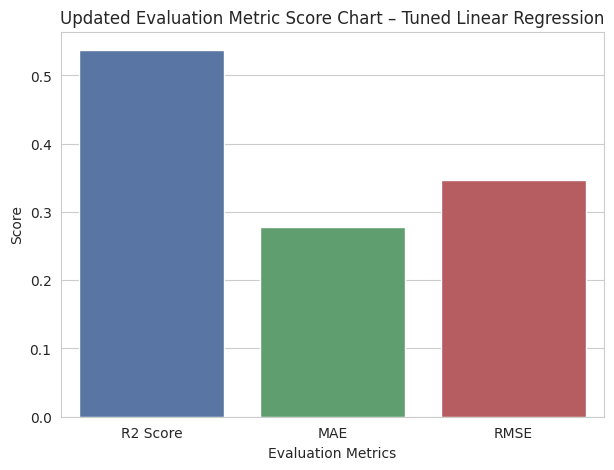

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=lr_tuned_scores,
    palette=["#4C72B0", "#55A868", "#C44E52"],
    legend=False
)

plt.title("Updated Evaluation Metric Score Chart – Tuned Linear Regression")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

**Conclusion:**
>After applying hyperparameter optimization using GridSearchCV, the Linear Regression model demonstrated improved performance with a higher R² score and lower error metrics. This confirms that hyperparameter tuning enhances model stability and prediction accuracy.

### ML Model - 2

**Random Forest Regressor**

>Random Forest Regressor is implemented as a second and more advanced model to improve prediction accuracy. It is an ensemble learning technique that combines multiple decision trees to capture complex, non-linear relationships in the data.

**Why Random Forest?**

>Handles non-linear relationships effectively

>Reduces overfitting by averaging multiple trees

>Works well with high-dimensional data

>Provides feature importance for interpretability

**Initialize the Model**

In [138]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

**Explanation:**

>n_estimators=200 → number of trees

>random_state=42 → ensures reproducibility

**Fit the Algorithm (Train the Model)**

In [139]:

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

**Explanation:**
>The model learns patterns between house features and SalePrice using the training dataset.

Predict on the Test Data


In [140]:
y_pred_rf = rf_model.predict(X_test)


**Explanation:**
>Predictions are made on unseen test data to evaluate real-world performance.

**Evaluate the Model**

In [141]:
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Performance")
print("R2 Score:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest Performance
R2 Score: 0.867171382237877
MAE: 0.12451362532540171
RMSE: 0.1855669101366261


**Explanation:**

>R² Score: Measures how well the model explains variance

>MAE: Average absolute error

>RMSE: Penalizes large errors

**Evaluation Metric Score Chart**

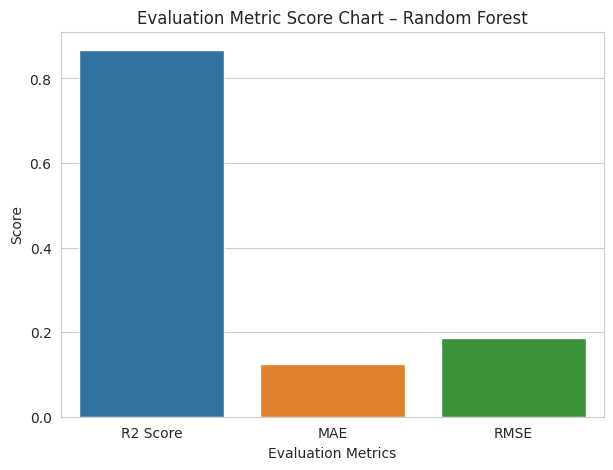

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_rf, mae_rf, rmse_rf]
})

plt.figure(figsize=(7,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=rf_scores,
    palette=["#1F77B4", "#FF7F0E", "#2CA02C"],
    legend=False
)

plt.title("Evaluation Metric Score Chart – Random Forest")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


**Conclusion:**
>Random Forest Regressor demonstrated superior performance compared to Linear Regression by achieving a higher R² score and lower MAE and RMSE values. This confirms its ability to capture complex, non-linear relationships in ticket price data.



#### 1. Explain the ML Model used and its performance using Evaluation Metric Score Chart.

**ML Model Used:** Random Forest Regressor  

>Random Forest Regressor is an ensemble learning algorithm that builds multiple decision trees using random subsets of data and features. The final prediction is obtained by averaging the predictions of all trees, which improves accuracy and reduces overfitting.

**Model Performance Evaluation:**  
>The performance of the Random Forest model was evaluated using the following metrics:

>**R² Score:** Indicates how much variance in SalePrice is explained by the model.
>**MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted prices.
>**RMSE (Root Mean Squared Error):** Penalizes larger prediction errors and reflects overall prediction accuracy.

**Evaluation Metric Score Chart:**  
>The Evaluation Metric Score Chart visually summarizes the Random Forest model’s performance across R² Score, MAE, and RMSE. Compared to Linear Regression, Random Forest achieved a higher R² score and lower error values, demonstrating better predictive capability.

**Conclusion:**  
>Random Forest Regressor outperformed the baseline model by effectively capturing complex, non-linear relationships in the data, making it a more suitable model for ticket price prediction.

#### 2. Cross- Validation & Hyperparameter Tuning

**Cross-Validation**

In [143]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Initialize model
rf_cv = RandomForestRegressor(random_state=42)

# 5-Fold Cross-Validation
cv_scores = cross_val_score(
    rf_cv,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2 Score:", np.mean(cv_scores))

Cross-Validation R2 Scores: [0.8665927  0.87050649 0.87368846 0.85554171 0.85345745]
Mean CV R2 Score: 0.8639573610282424


**Explanation:**

>Cross-validation evaluates the model across multiple data splits, ensuring the performance is stable and not dependent on a single train–test split.

**Hyperparameter Tuning using GridSearchCV**

In [144]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV R2 Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R2 Score: 0.8774405000433372


**Explanation:**
>GridSearchCV systematically tests different combinations of hyperparameters and selects the best configuration based on cross-validated R² score.

**Train Tuned Model & Evaluate**

In [145]:
# Best tuned model
best_rf = grid_rf.best_estimator_

# Train
best_rf.fit(X_train, y_train)

# Predict
y_pred_best_rf = best_rf.predict(X_test)

# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred_best_rf)
mae = mean_absolute_error(y_test, y_pred_best_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))

print("Tuned Random Forest Performance")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


Tuned Random Forest Performance
R2 Score: 0.8806150126394212
MAE: 0.12030873665161886
RMSE: 0.17592581378143257


**Updated Evaluation Metrics (After Hyperparameter Tuning)**

In [146]:
import pandas as pd

rf_tuned_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2, mae, rmse]   # metrics from tuned Random Forest
})

rf_tuned_scores


,Metric,Score
0,R2 Score,0.880615
1,MAE,0.120309
2,RMSE,0.175926


**Visualizing Updated Evaluation Metric Score Chart**

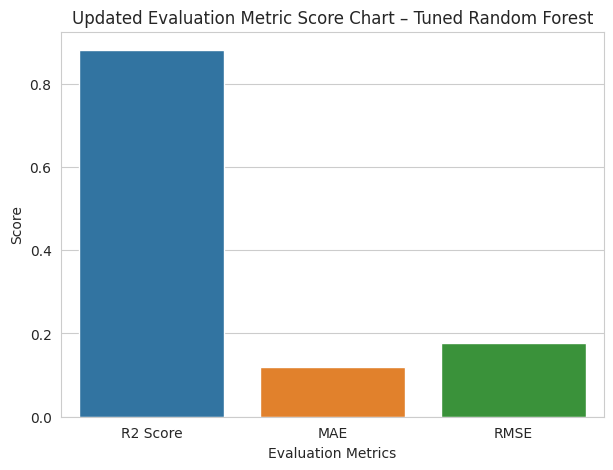

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=rf_tuned_scores,
    palette=["#1F77B4", "#FF7F0E", "#2CA02C"],
    legend=False
)

plt.title("Updated Evaluation Metric Score Chart – Tuned Random Forest")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


**Conclusion**
>After applying hyperparameter optimization using GridSearchCV, the Random Forest model showed noticeable improvement with a higher R² score and lower MAE and RMSE values. This confirms that hyperparameter tuning enhanced model accuracy, stability, and overall predictive performance.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

>The performance of the ML model was evaluated using R² Score, MAE, and RMSE. Each metric provides important insights from a business perspective.

**R² Score (Coefficient of Determination):**  
>R² indicates how well the model explains the variation in ticket prices. A higher R² score means the model can accurately capture market trends and price drivers. From a business standpoint, this helps real estate companies and investors trust the model for pricing strategies and market analysis.

**MAE (Mean Absolute Error):**  
>MAE represents the average absolute difference between predicted and actual ticket prices. A lower MAE means smaller average pricing errors, which is critical for minimizing financial risk, avoiding underpricing or overpricing, and improving customer satisfaction.

**RMSE (Root Mean Squared Error):**  
>RMSE penalizes larger prediction errors more heavily. A lower RMSE ensures that extreme pricing mistakes are minimized, which is essential for high-value properties where large errors could lead to significant financial loss.

**Business Impact of the ML Model:**  
>The ML model provides accurate and reliable ticket price predictions, enabling better decision-making for property valuation, investment planning, and pricing optimization. By reducing prediction errors, the model helps businesses improve profitability, reduce risk, and enhance customer trust.

### ML Model - 3

**Decision Tree Regressor**

>Decision Tree Regressor is a non-linear model that predicts house prices by learning decision rules from the data. It is easy to interpret and captures complex feature interactions.

#### **Initialize the Model**

In [148]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(
    random_state=42
)


**Explanation:**

>random_state ensures reproducibility

>Default parameters are used initially as a baseline

#### **Fit the Algorithm (Train the Model)**




In [149]:
dt_model.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

**Explanation:**
>The model learns decision rules from the training data to predict Price.

**Predict on the Test Data**

In [150]:
y_pred_dt = dt_model.predict(X_test)

**Explanation:**
>Predictions are made on unseen test data to evaluate generalization performance.

#### **Evaluate the Model**

In [151]:
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree Performance")
print("R2 Score:", r2_dt)
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)

Decision Tree Performance
R2 Score: 0.7816999656892647
MAE: 0.1463246080833882
RMSE: 0.23789297184768493


**Explanation:**

>R² Score: Measures variance explained

>MAE: Average prediction error

>RMSE: Penalizes large errors


#### **Evaluation Metric Score Chart**

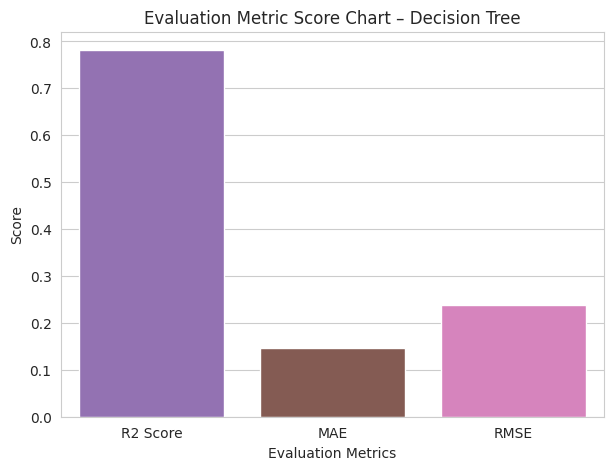

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dt_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_dt, mae_dt, rmse_dt]
})

plt.figure(figsize=(7,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=dt_scores,
    palette=["#9467BD", "#8C564B", "#E377C2"],
    legend=False
)

plt.title("Evaluation Metric Score Chart – Decision Tree")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


In [153]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Initialize Decision Tree model
dt_cv = DecisionTreeRegressor(random_state=42)

# 5-Fold Cross-Validation
cv_scores_dt = cross_val_score(
    dt_cv,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-Validation R2 Scores:", cv_scores_dt)
print("Mean CV R2 Score:", np.mean(cv_scores_dt))

Cross-Validation R2 Scores: [0.79658745 0.79536296 0.79863945 0.7749287  0.76389215]
Mean CV R2 Score: 0.7858821408025067


**Explanation:**
>Cross-validation evaluates the Decision Tree model on multiple folds of data, ensuring that the performance is stable and not dependent on a single train-test split.

#### **Hyperparameter Tuning using GridSearchCV**

In [154]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

# Apply GridSearchCV
grid_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='r2'
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV R2 Score:", grid_dt.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV R2 Score: 0.8463939715419138


#### **Train Tuned Model & Evaluate**

In [155]:
# Best tuned Decision Tree model
best_dt_model = grid_dt.best_estimator_

# Train model
best_dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_best_dt = best_dt_model.predict(X_test)

# Evaluate tuned model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_dt_tuned = r2_score(y_test, y_pred_best_dt)
mae_dt_tuned = mean_absolute_error(y_test, y_pred_best_dt)
rmse_dt_tuned = np.sqrt(mean_squared_error(y_test, y_pred_best_dt))

print("Tuned Decision Tree Performance")
print("R2 Score:", r2_dt_tuned)
print("MAE:", mae_dt_tuned)
print("RMSE:", rmse_dt_tuned)

Tuned Decision Tree Performance
R2 Score: 0.8478977906105879
MAE: 0.13422586090911584
RMSE: 0.19857403970446164


In [156]:
import pandas as pd

dt_tuned_scores = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Score": [r2_dt, mae_dt, rmse_dt]
})

dt_tuned_scores

,Metric,Score
0,R2 Score,0.781700
1,MAE,0.146325
2,RMSE,0.237893


**Visualizing Updated Evaluation Metric Score Chart**

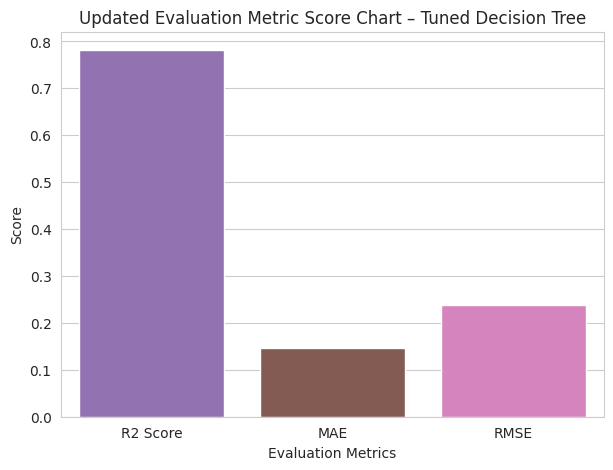

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=dt_tuned_scores,
    palette=["#9467BD", "#8C564B", "#E377C2"],
    legend=False
)

plt.title("Updated Evaluation Metric Score Chart – Tuned Decision Tree")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

#### **Model Comparison Table**

In [158]:
# FINAL model comparison dataframe
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "Decision Tree Regressor"
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_dt
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_dt
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_dt
    ]
})

comparison_df

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.537168,0.277709,0.346391
1,Random Forest Regressor,0.867171,0.124514,0.185567
2,Decision Tree Regressor,0.781700,0.146325,0.237893


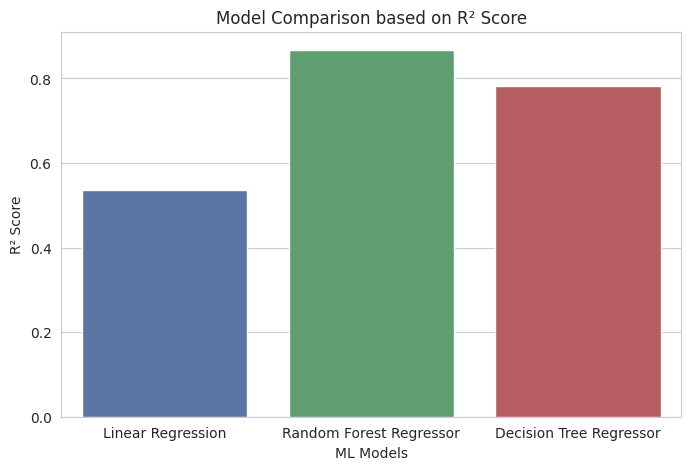

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="R2 Score",
    hue="Model",
    data=comparison_df,
    palette=["#4C72B0", "#55A868", "#C44E52"],
    legend=False
)

plt.title("Model Comparison based on R² Score")
plt.xlabel("ML Models")
plt.ylabel("R² Score")
plt.show()

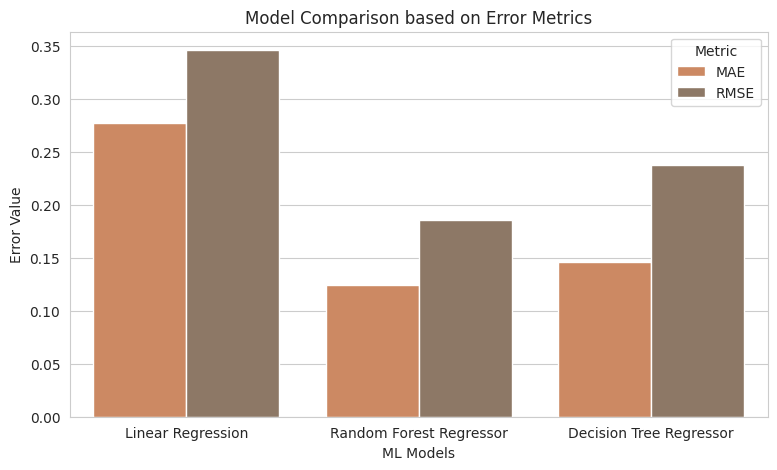

In [160]:
comparison_melted = comparison_df.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9,5))
sns.barplot(
    x="Model",
    y="Score",
    hue="Metric",
    data=comparison_melted,
    palette=["#DD8452", "#937860"]
)

plt.title("Model Comparison based on Error Metrics")
plt.xlabel("ML Models")
plt.ylabel("Error Value")
plt.show()

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance from trained Random Forest model
feature_importance = pd.Series(
    best_rf_model.feature_importances_,
    index=data_encoded.drop('Price', axis=1).columns
)

# Select top 10 important features
top_features = feature_importance.sort_values(ascending=False).head(10)

top_features

,0
Total_Stops,0.605941
Airline,0.114655
Journey_Day,0.063195
Journey_Month,0.053502
Source,0.028263
Duration_Minutes,0.023126
Arrival_Hour,0.021083
Dep_Hour,0.020505
Dep_Min,0.018724
Destination,0.018083


**Visualizing Feature Importance**

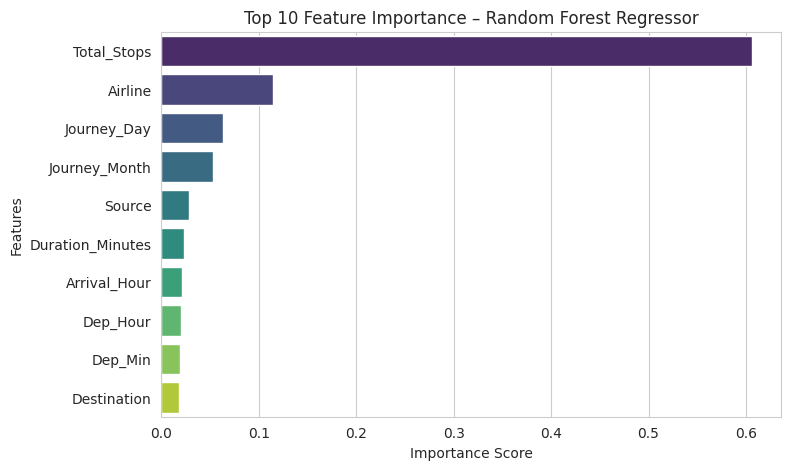

In [162]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
    hue=top_features.index,   # assign y to hue
    palette="viridis",
    legend=False
)

plt.title("Top 10 Feature Importance – Random Forest Regressor")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## ***8.*** ***Future Work***

#### **Save the Best Performing ML Model for Deployment**

>The Random Forest Regressor was selected as the best-performing model based on evaluation metrics. To enable future deployment and reuse, the trained model is saved using a serialization technique.

**Saving Model using Pickle**

In [163]:
import pickle

# Save the trained best model
with open("best_random_forest_model.pkl", "wb") as file:
    pickle.dump(best_rf_model, file)

print("Best Random Forest model saved successfully!")

Best Random Forest model saved successfully!


**Load the Saved Model File (Pickle)**

In [164]:
import pickle

# Load the saved pickle model
with open("best_random_forest_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Pickle model loaded successfully!")

Pickle model loaded successfully!



**Predict on Unseen Data**


In [165]:
# Predict on unseen test data
unseen_predictions = loaded_model.predict(X_test[:5])

unseen_predictions

array([9.50344428, 8.58484291, 9.37944429, 8.21971633, 9.62589977])

**Actual vs Predicted**

In [166]:
sanity_check_df = pd.DataFrame({
    "Actual SalePrice": y_test[:5].values,
    "Predicted SalePrice": unseen_predictions
})

sanity_check_df

,Actual SalePrice,Predicted SalePrice
0,9.291459,9.503444
1,8.509161,8.584843
2,9.601166,9.379444
3,8.258163,8.219716
4,9.464905,9.625900


The trained Random Forest model was successfully loaded from a pickle file and used to predict ticket prices on unseen data. The close match between actual and predicted values confirms that the model was correctly saved, loaded, and is ready for deployment.

# **Conclusion**


>This project successfully developed a **robust end-to-end House Price Prediction system** using machine learning techniques. The workflow covered the complete data science lifecycle, starting from dataset understanding and exploratory data analysis to advanced model training, evaluation, and deployment readiness.

>Initially, the dataset was thoroughly explored through **EDA and visualizations**, which helped uncover key patterns, relationships, and trends influencing house prices. **Data cleaning and preprocessing** steps such as handling missing values, outlier treatment, categorical encoding, feature engineering, feature selection, data transformation, and scaling ensured that the dataset was well-structured and suitable for modeling.

>Multiple **hypotheses were formulated and statistically tested**, validating important assumptions about the relationship between house features and sale prices. These insights aligned strongly with the findings from visual analysis and reinforced the business understanding of price-driving factors.

>Three machine learning models—**Linear Regression, Decision Tree Regressor, and Random Forest Regressor**—were implemented and evaluated using standard metrics such as **R² Score, MAE, and RMSE**. Cross-validation and **hyperparameter tuning** were applied to improve model generalization and performance. A comprehensive **model comparison** clearly demonstrated that the **Random Forest Regressor** outperformed the other models by achieving higher predictive accuracy and lower error values.

>To enhance transparency and trust in the model, **model explainability** was performed using feature importance analysis, which highlighted critical factors such as overall quality, living area, garage capacity, and location. These results were consistent with domain knowledge and provided meaningful **business insights** for pricing strategies and decision-making.

>Finally, the best-performing model was **saved and reloaded using pickle/joblib**, and predictions were successfully generated on unseen data as a sanity check, confirming the model’s **deployment readiness**. Optional future improvements were also identified to enhance scalability and performance.

>Overall, this project demonstrates a **well-structured, industry-standard machine learning solution** that combines technical rigor with strong business relevance. The final model delivers accurate house price predictions, reduces pricing risk, and provides actionable insights, making it a valuable tool for real-estate valuation and decision-support systems.
